# **FRAMEWORK V7 DATASET MAESTRO - CATALOGO DEL CONOCIMIENTO**

## **M0. Configuración**

In [1]:
#==========================================================
# CONFIGURACIÓN
#==========================================================

import pandas as pd
import numpy as np
from pathlib import Path

#==========================================================
# DATASET OFICIAL DEL FRAMEWORK
#==========================================================

URL_DATASET = (
    "https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/MASTER/C09_MASTER/Dataset_Maestro_Framework_v04.parquet"
)

print("Cargando Dataset Maestro V04...")

dataset_maestro_v04 = pd.read_parquet(URL_DATASET)

print("Dataset cargado correctamente.")

Cargando Dataset Maestro V04...
Dataset cargado correctamente.


In [2]:
print("=" * 70)
print("VALIDACIÓN ENTRADA C10")
print("=" * 70)

print("\nDimensiones:")
print(dataset_maestro_v04.shape)

print("\nIRCA:")
print("dtype:", dataset_maestro_v04["irca"].dtype)
print("Nulos:", dataset_maestro_v04["irca"].isna().sum())
print(
    "Rango:",
    dataset_maestro_v04["irca"].min(),
    "-",
    dataset_maestro_v04["irca"].max()
)

print("\nVolumen:")
print("dtype:", dataset_maestro_v04["VolumenUtilDiarioMasa"].dtype)
print(
    "Disponibles:",
    dataset_maestro_v04["VolumenUtilDiarioMasa"].notna().sum()
)
print(
    "Nulos:",
    dataset_maestro_v04["VolumenUtilDiarioMasa"].isna().sum()
)
print(
    "Rango:",
    dataset_maestro_v04["VolumenUtilDiarioMasa"].min(),
    "-",
    dataset_maestro_v04["VolumenUtilDiarioMasa"].max()
)

print("\nBanderas de trazabilidad:")

banderas = [
    "IRCA_Imputado",
    "Volumen_Imputado",
    "Poblacion_Imputada",
    "Densidad_Imputada",
    "AguaPotable_Imputada",
    "Saneamiento_Imputado",
    "AcueductoUrbano_Imputado",
    "AcueductoRural_Imputado",
    "AlcantarilladoUrbano_Imputado",
    "AlcantarilladoRural_Imputado"
]

for columna in banderas:
    print(
        columna,
        "PRESENTE" if columna in dataset_maestro_v04.columns
        else "FALTA"
    )

VALIDACIÓN ENTRADA C10

Dimensiones:
(528, 52)

IRCA:
dtype: float64
Nulos: 0
Rango: 0.0 - 9.5

Volumen:
dtype: float64
Disponibles: 336
Nulos: 192
Rango: 290141870.9677419 - 619585580.6451613

Banderas de trazabilidad:
IRCA_Imputado PRESENTE
Volumen_Imputado PRESENTE
Poblacion_Imputada PRESENTE
Densidad_Imputada PRESENTE
AguaPotable_Imputada PRESENTE
Saneamiento_Imputado PRESENTE
AcueductoUrbano_Imputado PRESENTE
AcueductoRural_Imputado PRESENTE
AlcantarilladoUrbano_Imputado PRESENTE
AlcantarilladoRural_Imputado PRESENTE


## **M1 Perfil del Dataset Maestro**

In [3]:
#==========================================================
# INFORMACIÓN GENERAL DEL DATASET
#==========================================================

print("\n" + "="*90)
print("PERFIL GENERAL DEL DATASET")
print("="*90)

print(f"Registros : {dataset_maestro_v04.shape[0]:,}")
print(f"Variables : {dataset_maestro_v04.shape[1]:,}")

print("\nPrimeras variables")

print(dataset_maestro_v04.columns.tolist())


PERFIL GENERAL DEL DATASET
Registros : 528
Variables : 52

Primeras variables
['Nodo', 'Fecha', 'Precipitacion_mm', 'Temp_Max_C', 'Temp_Min_C', 'Temp_Media_C', 'Humedad_Relativa', 'Velocidad_Viento', 'Radiacion_Solar', 'Anio', 'Mes', 'ONI', 'Estado_ENSO', 'VolumenUtilDiarioMasa', 'irca', 'nivel_de_riesgo', 'POBLACION TOTAL', 'DENSIDAD POBLACIONAL', 'INDICE DE DESEMPENO INSTITUCIONAL', 'ACCESO A AGUA POTABLE ADECUADO', 'PORCENTAJE DE LA POBLACION CON ACCESO A METODOS DE SANEAMIENTO ADECUADOS', 'COBERTURA DE ACUEDUCTO URBANO', 'COBERTURA DE ACUEDUCTO RURAL', 'COBERTURA DE ALCANTARILLADO URBANO', 'COBERTURA DE ALCANTARILLADO RURAL', 'CONTINUIDAD DE ACUEDUCTO URBANO', 'CALIDAD DEL AGUA', 'AGUAS RESIDUALES TRATADAS', 'Nivel_Minimo', 'CONDUCTIVIDAD ELECTRICA', 'DEMANDA BIOQUIMICA DE OXIGENO (DBO5)', 'DEMANDA QUIMICA DE OXIGENO (DQO)', 'FOSFORO TOTAL', 'NITROGENO TOTAL', 'OXIGENO DISUELTO (OD)', 'SOLIDOS SUSPENDIDOS TOTALES', 'TEMPERATURA', 'TURBIDEZ', 'pH', 'IRCA_Imputado', 'Volumen_Imputad

In [4]:
#==========================================================
# TIPOS DE VARIABLES
#==========================================================

tipos_variables = pd.DataFrame({
    "Variable": dataset_maestro_v04.columns,
    "Tipo": dataset_maestro_v04.dtypes.astype(str)
})

print("\nTipos de variables")

print(tipos_variables)


Tipos de variables
                                                                                             Variable  \
Nodo                                                                                             Nodo   
Fecha                                                                                           Fecha   
Precipitacion_mm                                                                     Precipitacion_mm   
Temp_Max_C                                                                                 Temp_Max_C   
Temp_Min_C                                                                                 Temp_Min_C   
Temp_Media_C                                                                             Temp_Media_C   
Humedad_Relativa                                                                     Humedad_Relativa   
Velocidad_Viento                                                                     Velocidad_Viento   
Radiacion_Solar                    

In [5]:
#==========================================================
# CLASIFICACIÓN DE VARIABLES
#==========================================================

variables_numericas = dataset_maestro_v04.select_dtypes(
    include=["number"]
).columns.tolist()

variables_categoricas = dataset_maestro_v04.select_dtypes(
    include=["object","category"]
).columns.tolist()

variables_fecha = dataset_maestro_v04.select_dtypes(
    include=["datetime64[ns]"]
).columns.tolist()

In [6]:
print("\nResumen")

print(f"Variables numéricas    : {len(variables_numericas)}")
print(f"Variables categóricas  : {len(variables_categoricas)}")
print(f"Variables fecha        : {len(variables_fecha)}")


Resumen
Variables numéricas    : 45
Variables categóricas  : 6
Variables fecha        : 1


In [7]:
#==========================================================
# MEMORIA
#==========================================================

memoria = dataset_maestro_v04.memory_usage(deep=True).sum()/1024**2

print(f"\nMemoria utilizada : {memoria:.2f} MB")


Memoria utilizada : 0.36 MB


In [8]:
#==========================================================
# DUPLICADOS
#==========================================================

duplicados = dataset_maestro_v04.duplicated().sum()

print(f"\nRegistros duplicados : {duplicados}")


Registros duplicados : 0


In [9]:
#==========================================================
# COMPLETITUD GENERAL
#==========================================================

total_celdas = (
    dataset_maestro_v04.shape[0] *
    dataset_maestro_v04.shape[1]
)

celdas_validas = dataset_maestro_v04.notna().sum().sum()

completitud = (
    celdas_validas /
    total_celdas
)*100

print(f"\nCompletitud general : {completitud:.2f}%")


Completitud general : 73.59%


In [10]:
#==========================================================
# RESUMEN GENERAL
#==========================================================

perfil_general = pd.DataFrame({

    "Indicador":[
        "Registros",
        "Variables",
        "Variables numéricas",
        "Variables categóricas",
        "Variables fecha",
        "Duplicados",
        "Memoria (MB)",
        "Completitud (%)"
    ],

    "Valor":[
        dataset_maestro_v04.shape[0],
        dataset_maestro_v04.shape[1],
        len(variables_numericas),
        len(variables_categoricas),
        len(variables_fecha),
        duplicados,
        round(memoria,2),
        round(completitud,2)
    ]

})

print(perfil_general)

               Indicador   Valor
0              Registros  528.00
1              Variables   52.00
2    Variables numéricas   45.00
3  Variables categóricas    6.00
4        Variables fecha    1.00
5             Duplicados    0.00
6           Memoria (MB)    0.36
7        Completitud (%)   73.59


In [11]:
#==========================================================
# EXPORTAR RESULTADOS
#==========================================================
#
# Este bloque genera los productos del Script_Perfil_General_Dataset.
#
# perfil_general_dataset.csv
#     Tabla resumen con los principales indicadores del
#     Dataset Maestro V04.
#
# perfil_general_dataset.xlsx
#     Versión en Excel para análisis y documentación.
#
# perfil_general_dataset.md
#     Resumen en formato Markdown para incorporar
#     directamente en la tesis o documentación técnica.
#
#==========================================================

perfil_general.to_csv(
    "Perfil_general_Dataset_Maestro_Framework_v04.csv",
    index=False,
    encoding="utf-8-sig"
)

perfil_general.to_excel(
    "Perfil_general_Dataset_Maestro_Framework_v04.xlsx",
    index=False
)

perfil_general.to_markdown(
    "Perfil_general_Dataset_Maestro_Framework_v04.md",
    index=False
)

print("\nArchivos generados correctamente:")
print("   Perfil_general_Dataset_Maestro_Framework_v04.csv")
print("   Perfil_general_Dataset_Maestro_Framework_v04.xlsx")
print("   Perfil_general_Dataset_Maestro_Framework_v04.md")


Archivos generados correctamente:
   Perfil_general_Dataset_Maestro_Framework_v04.csv
   Perfil_general_Dataset_Maestro_Framework_v04.xlsx
   Perfil_general_Dataset_Maestro_Framework_v04.md


## **M2. Calidad de Datos del Dataset Maestro V04**

In [12]:
#==========================================================
# SCRIPT
# CALIDAD DE DATOS
#==========================================================

import pandas as pd
import numpy as np

URL_DATASET = (
    "https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/MASTER/C09_MASTER/Dataset_Maestro_Framework_v04.parquet"
)

print("Cargando Dataset Maestro V04...")

dataset_maestro_v04 = pd.read_parquet(URL_DATASET)

print("Dataset cargado correctamente.")

Cargando Dataset Maestro V04...
Dataset cargado correctamente.


In [13]:
#==========================================================
# PERFIL DE VARIABLES
#==========================================================

reporte = []

In [14]:
for variable in dataset_maestro_v04.columns:

    serie = dataset_maestro_v04[variable]

    total = len(serie)

    nulos = serie.isna().sum()

    completos = total - nulos

    cobertura = completos / total * 100

    unicos = serie.nunique(dropna=True)

    duplicados = completos - unicos

    tipo = str(serie.dtype)

    porcentaje_nulos = nulos / total * 100

    porcentaje_ceros = (
        (serie == 0).sum() / total * 100
        if pd.api.types.is_numeric_dtype(serie)
        else np.nan
    )

    reporte.append({
        "Variable":variable,
        "Tipo":tipo,
        "Registros":total,
        "Completos":completos,
        "Nulos":nulos,
        "% Cobertura":round(cobertura,2),
        "% Nulos":round(porcentaje_nulos,2),
        "Valores Únicos":unicos,
        "Duplicados":duplicados,
        "% Ceros":round(porcentaje_ceros,2)
    })

In [15]:
calidad = pd.DataFrame(reporte)

In [16]:
print("Dimensiones del perfil:", calidad.shape)

variables_validacion = [
    "irca",
    "VolumenUtilDiarioMasa",
    "IRCA_Imputado",
    "Volumen_Imputado",
    "Poblacion_Imputada"
]

print(
    calidad[
        calidad["Variable"].isin(variables_validacion)
    ][
        [
            "Variable",
            "Tipo",
            "Registros",
            "Completos",
            "Nulos",
            "% Cobertura",
            "Valores Únicos",
            "% Ceros"
        ]
    ].to_string(index=False)
)

Dimensiones del perfil: (52, 10)
             Variable    Tipo  Registros  Completos  Nulos  % Cobertura  Valores Únicos  % Ceros
VolumenUtilDiarioMasa float64        528        336    192        63.64              84     0.00
                 irca float64        528        528      0       100.00              29     9.09
        IRCA_Imputado   int64        528        528      0       100.00               2    90.91
     Volumen_Imputado   int64        528        528      0       100.00               2    91.67
   Poblacion_Imputada   int64        528        528      0       100.00               2    36.36


In [17]:
def clasificacion(cobertura):

    if cobertura >= 95:
        return "A - Excelente"

    elif cobertura >= 80:
        return "B - Buena"

    elif cobertura >= 50:
        return "C - Media"

    else:
        return "D - Baja"

In [18]:
calidad["Calificación"] = calidad["% Cobertura"].apply(clasificacion)

In [19]:
print(
    calidad["Calificación"]
    .value_counts()
)

print("\nVolumen:")
print(
    calidad.loc[
        calidad["Variable"] == "VolumenUtilDiarioMasa",
        ["Variable", "% Cobertura", "Calificación"]
    ].to_string(index=False)
)

Calificación
A - Excelente    36
D - Baja         15
C - Media         1
Name: count, dtype: int64

Volumen:
             Variable  % Cobertura Calificación
VolumenUtilDiarioMasa        63.64    C - Media


In [20]:
#==========================================================
# RECOMENDACIÓN SEGÚN COMPLETITUD
#==========================================================
#
# Esta recomendación se refiere únicamente al tratamiento
# de valores faltantes.
#
# La pertinencia de una variable para Machine Learning
# será evaluada posteriormente mediante el IPML.
#==========================================================

def recomendacion(fila):

    cobertura = fila["% Cobertura"]

    if cobertura >= 95:
        return "Sin tratamiento por faltantes"

    elif cobertura >= 80:
        return "Revisar imputación simple"

    elif cobertura >= 50:
        return "Requiere estrategia para datos faltantes"

    else:
        return "Cobertura insuficiente; revisar uso"

In [21]:
calidad["Recomendación"] = calidad.apply(
    recomendacion,
    axis=1
)

In [22]:
print(
    calidad.loc[
        calidad["Variable"].isin([
            "irca",
            "VolumenUtilDiarioMasa",
            "IRCA_Imputado"
        ]),
        [
            "Variable",
            "% Cobertura",
            "Calificación",
            "Recomendación"
        ]
    ].to_string(index=False)
)

             Variable  % Cobertura  Calificación                            Recomendación
VolumenUtilDiarioMasa        63.64     C - Media Requiere estrategia para datos faltantes
                 irca       100.00 A - Excelente            Sin tratamiento por faltantes
        IRCA_Imputado       100.00 A - Excelente            Sin tratamiento por faltantes


In [23]:
calidad = calidad.sort_values(
    "% Cobertura",
    ascending=False
)

In [24]:
print("Primeras 3:")
print(
    calidad[
        ["Variable", "% Cobertura", "Calificación"]
    ].head(3).to_string(index=False)
)

print("\nÚltimas 3:")
print(
    calidad[
        ["Variable", "% Cobertura", "Calificación"]
    ].tail(3).to_string(index=False)
)

Primeras 3:
        Variable  % Cobertura  Calificación
            Nodo        100.0 A - Excelente
           Fecha        100.0 A - Excelente
Precipitacion_mm        100.0 A - Excelente

Últimas 3:
                            Variable  % Cobertura Calificación
                            TURBIDEZ         6.44     D - Baja
                     NITROGENO TOTAL         5.49     D - Baja
DEMANDA BIOQUIMICA DE OXIGENO (DBO5)         4.92     D - Baja


In [25]:
print("\n")

print("="*110)

print("CALIDAD GENERAL DEL DATASET")

print("="*110)

print(calidad)



CALIDAD GENERAL DEL DATASET
                                             Variable            Tipo  \
0                                                Nodo          object   
1                                               Fecha  datetime64[ns]   
2                                    Precipitacion_mm         float64   
3                                          Temp_Max_C         float64   
4                                          Temp_Min_C         float64   
5                                        Temp_Media_C         float64   
6                                    Humedad_Relativa         float64   
7                                    Velocidad_Viento         float64   
8                                     Radiacion_Solar         float64   
9                                                Anio           int32   
10                                                Mes           int32   
11                                                ONI         float64   
12                   

In [26]:
print("Filas mostradas:", len(calidad))
print("Columnas:", calidad.columns.tolist())

Filas mostradas: 52
Columnas: ['Variable', 'Tipo', 'Registros', 'Completos', 'Nulos', '% Cobertura', '% Nulos', 'Valores Únicos', 'Duplicados', '% Ceros', 'Calificación', 'Recomendación']


In [27]:
print("\n")

print("="*70)

print("RESUMEN")

print("="*70)

print(calidad["Calificación"].value_counts())



RESUMEN
Calificación
A - Excelente    36
D - Baja         15
C - Media         1
Name: count, dtype: int64


In [28]:
#==========================================================
# EXPORTAR RESULTADOS DEL PERFIL DE CALIDAD
#==========================================================
#
# Análisis Exploratorio de Datos (EDA)
# Script: Calidad de Datos del Dataset Maestro V04
#
# Descripción:
#
#   Se exporta el perfil de calidad de cada variable del
#   Dataset Maestro V04.
#
#   El perfil incluye información como:
#
#       • Nombre de la variable
#       • Número de registros disponibles
#       • Valores faltantes
#       • Porcentaje de cobertura
#       • Clasificación de calidad
#
# Archivos generados:
#
#   calidad_variables.csv
#       Archivo interoperable para análisis y trazabilidad.
#
#   calidad_variables.xlsx
#       Archivo para revisión manual y documentación.
#
#   calidad_variables.md
#       Archivo en formato Markdown para incorporación
#       directa en la tesis y documentación técnica.
#
#==========================================================

calidad.to_csv(
    "Calidad_Variables_Dataset_Maestro_Framework_v04.csv",
    index=False,
    encoding="utf-8-sig"
)

calidad.to_excel(
    "Calidad_Variables_Dataset_Maestro_Framework_v04.xlsx",
    index=False
)

calidad.to_markdown(
    "Calidad_Variables_Dataset_Maestro_Framework_v04.md",
    index=False
)

print("\nArchivos generados correctamente:")
print("   Calidad_Variables_Dataset_Maestro_Framework_v04.csv")
print("   Calidad_Variables_Dataset_Maestro_Framework_v04.xlsx")
print("   Calidad_Variables_Dataset_Maestro_Framework_v04.md")


Archivos generados correctamente:
   Calidad_Variables_Dataset_Maestro_Framework_v04.csv
   Calidad_Variables_Dataset_Maestro_Framework_v04.xlsx
   Calidad_Variables_Dataset_Maestro_Framework_v04.md


## **M3. Estadisticas Descriptivas del Dataset Maestro V04**

In [29]:
import pandas as pd
import numpy as np

URL_DATASET = (
    "https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/MASTER/C09_MASTER/Dataset_Maestro_Framework_v04.parquet"
)

print("="*70)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("="*70)

dataset_maestro_v04 = pd.read_parquet(URL_DATASET)

#----------------------------------------------------------
# Seleccionar únicamente variables numéricas
#----------------------------------------------------------

COLUMNAS_TRAZABILIDAD = [
    "IRCA_Imputado",
    "Volumen_Imputado",
    "Poblacion_Imputada",
    "Densidad_Imputada",
    "AguaPotable_Imputada",
    "Saneamiento_Imputado",
    "AcueductoUrbano_Imputado",
    "AcueductoRural_Imputado",
    "AlcantarilladoUrbano_Imputado",
    "AlcantarilladoRural_Imputado"
]

variables_numericas = dataset_maestro_v04.select_dtypes(
    include=np.number
).drop(
    columns=COLUMNAS_TRAZABILIDAD,
    errors="ignore"
)

print("Variables numéricas analíticas:", variables_numericas.shape[1])

print("\nBanderas presentes por error:")
print(
    [
        c for c in COLUMNAS_TRAZABILIDAD
        if c in variables_numericas.columns
    ]
)

#----------------------------------------------------------
# Estadísticas
#----------------------------------------------------------

estadisticas = pd.DataFrame()

estadisticas["Tipo"] = variables_numericas.dtypes

estadisticas["Registros"] = variables_numericas.count()

estadisticas["Faltantes"] = variables_numericas.isna().sum()

estadisticas["Cobertura (%)"] = (
    estadisticas["Registros"] /
    len(dataset_maestro_v04) * 100
).round(2)

estadisticas["Media"] = variables_numericas.mean()

estadisticas["Mediana"] = variables_numericas.median()

estadisticas["Desv.Std"] = variables_numericas.std()

estadisticas["Varianza"] = variables_numericas.var()

estadisticas["Mínimo"] = variables_numericas.min()

estadisticas["P25"] = variables_numericas.quantile(.25)

estadisticas["P75"] = variables_numericas.quantile(.75)

estadisticas["Máximo"] = variables_numericas.max()

estadisticas["Valores únicos"] = variables_numericas.nunique()

estadisticas["Coeficiente Variación (%)"] = (
    estadisticas["Desv.Std"] /
    estadisticas["Media"] * 100
).round(2)

print()
print(estadisticas)

ESTADÍSTICAS DESCRIPTIVAS
Variables numéricas analíticas: 35

Banderas presentes por error:
[]

                                                       Tipo  Registros  \
Precipitacion_mm                                    float64        528   
Temp_Max_C                                          float64        528   
Temp_Min_C                                          float64        528   
Temp_Media_C                                        float64        528   
Humedad_Relativa                                    float64        528   
Velocidad_Viento                                    float64        528   
Radiacion_Solar                                     float64        528   
Anio                                                  int32        528   
Mes                                                   int32        528   
ONI                                                 float64        528   
VolumenUtilDiarioMasa                               float64        336   
irca            

In [30]:
variables_porcentaje = [
    "ACCESO A AGUA POTABLE ADECUADO",
    "PORCENTAJE DE LA POBLACION CON ACCESO A METODOS DE SANEAMIENTO ADECUADOS",
    "COBERTURA DE ACUEDUCTO URBANO",
    "COBERTURA DE ACUEDUCTO RURAL",
    "COBERTURA DE ALCANTARILLADO URBANO",
    "COBERTURA DE ALCANTARILLADO RURAL"
]

for variable in variables_porcentaje:

    fuera_rango = dataset_maestro_v04[
        dataset_maestro_v04[variable].notna() &
        (
            (dataset_maestro_v04[variable] < 0) |
            (dataset_maestro_v04[variable] > 100)
        )
    ]

    print("\n" + "="*90)
    print(variable)
    print("="*90)
    print("Valores fuera de [0,100]:", len(fuera_rango))

    if len(fuera_rango) > 0:
        columnas_mostrar = [
            "Nodo",
            "Fecha",
            "Anio",
            "Mes",
            variable
        ]

        print(
            fuera_rango[columnas_mostrar]
            .to_string(index=False)
        )


ACCESO A AGUA POTABLE ADECUADO
Valores fuera de [0,100]: 0

PORCENTAJE DE LA POBLACION CON ACCESO A METODOS DE SANEAMIENTO ADECUADOS
Valores fuera de [0,100]: 0

COBERTURA DE ACUEDUCTO URBANO
Valores fuera de [0,100]: 0

COBERTURA DE ACUEDUCTO RURAL
Valores fuera de [0,100]: 0

COBERTURA DE ALCANTARILLADO URBANO
Valores fuera de [0,100]: 0

COBERTURA DE ALCANTARILLADO RURAL
Valores fuera de [0,100]: 0


In [31]:
pares_revision = {
    "ACCESO A AGUA POTABLE ADECUADO":
        "AguaPotable_Imputada",

    "PORCENTAJE DE LA POBLACION CON ACCESO A METODOS DE SANEAMIENTO ADECUADOS":
        "Saneamiento_Imputado",

    "COBERTURA DE ALCANTARILLADO URBANO":
        "AlcantarilladoUrbano_Imputado"
}

for variable, bandera in pares_revision.items():

    tmp = dataset_maestro_v04[
        ["Anio", variable, bandera]
    ].copy()

    tmp["Fuera_Rango"] = (
        (tmp[variable] < 0) |
        (tmp[variable] > 100)
    ).astype(int)

    resumen = tmp.groupby("Anio").agg(
        Registros=(variable, "count"),
        Imputados=(bandera, "sum"),
        Minimo=(variable, "min"),
        Maximo=(variable, "max"),
        Fuera_Rango=("Fuera_Rango", "sum")
    )

    print("\n" + "="*95)
    print(variable)
    print("="*95)
    print(resumen)


ACCESO A AGUA POTABLE ADECUADO
      Registros  Imputados  Minimo  Maximo  Fuera_Rango
Anio                                                   
2015         48         48   89.00   100.0            0
2016         48         48   89.00   100.0            0
2017         48         48   89.00   100.0            0
2018         48         48   89.00   100.0            0
2019         48         48   89.00   100.0            0
2020         48         48   89.00   100.0            0
2021         48          0   89.00   100.0            0
2022         48          0   90.00   100.0            0
2023         48          0   89.95   100.0            0
2024         48          0   99.70   100.0            0
2025         48         48   99.70   100.0            0

PORCENTAJE DE LA POBLACION CON ACCESO A METODOS DE SANEAMIENTO ADECUADOS
      Registros  Imputados  Minimo  Maximo  Fuera_Rango
Anio                                                   
2015         48         48   89.00  100.00            

In [32]:
#==========================================================
# EXPORTAR ESTADÍSTICAS DESCRIPTIVAS
#==========================================================
#
# Se exporta el resumen estadístico de todas las variables
# numéricas del Dataset Maestro V04.
#
# Contenido:
#     • Tendencia central
#     • Dispersión
#     • Cobertura
#     • Valores únicos
#     • Variabilidad
#
#==========================================================

estadisticas.to_csv(
    "Estadisticas_Descriptivas_Dataset_Maestro_Framework_v04.csv",
    index=True,
    encoding="utf-8-sig"
)

estadisticas.to_excel(
    "Estadisticas_Descriptivas_Dataset_Maestro_Framework_v04.xlsx"
)

estadisticas.to_markdown(
    "Estadisticas_Descriptivas_Dataset_Maestro_Framework_v04.md"
)

print("\nArchivos generados correctamente:")
print("   Estadisticas_Descriptivas_Dataset_Maestro_Framework_v04.csv")
print("   Estadisticas_Descriptivas_Dataset_Maestro_Framework_v04.xlsx")
print("   Estadisticas_Descriptivas_Dataset_Maestro_Framework_v04.md")


Archivos generados correctamente:
   Estadisticas_Descriptivas_Dataset_Maestro_Framework_v04.csv
   Estadisticas_Descriptivas_Dataset_Maestro_Framework_v04.xlsx
   Estadisticas_Descriptivas_Dataset_Maestro_Framework_v04.md


## **M4. Distribuciones Univariadas del Dataset Maestro V04**

In [33]:
#==========================================================
# FRAMEWORK PARA LA GESTIÓN INTELIGENTE DEL RECURSO HÍDRICO
#
# Análisis Exploratorio de Datos (EDA)
#
# Script
# Distribuciones Univariadas
#
# Objetivo
# ---------
# Analizar la distribución estadística de todas las
# variables numéricas del Dataset Maestro V04 mediante
# histogramas.
#
# Para cada variable se genera:
#
#   • Histograma
#   • Línea de la media
#   • Línea de la mediana
#   • Estadísticos básicos
#
# Los gráficos serán utilizados en la tesis y para
# apoyar la selección de variables del Framework.
#
# Fuente:
# Dataset Maestro V04 (GitHub)
#
#==========================================================

import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

#==========================================================
# CARGAR DATASET MAESTRO V04
#==========================================================

print("Cargando Dataset Maestro V04...")

url = (
    "https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/MASTER/C09_MASTER/Dataset_Maestro_Framework_v04.parquet"
)

dataset = pd.read_parquet(url)

print("Dataset cargado correctamente.")

Cargando Dataset Maestro V04...
Dataset cargado correctamente.


In [34]:
#==========================================================
# CREAR CARPETA DE RESULTADOS
#==========================================================

carpeta = "EDA_Distribuciones"

os.makedirs(carpeta, exist_ok=True)

In [35]:
COLUMNAS_TRAZABILIDAD = [
    "IRCA_Imputado",
    "Volumen_Imputado",
    "Poblacion_Imputada",
    "Densidad_Imputada",
    "AguaPotable_Imputada",
    "Saneamiento_Imputado",
    "AcueductoUrbano_Imputado",
    "AcueductoRural_Imputado",
    "AlcantarilladoUrbano_Imputado",
    "AlcantarilladoRural_Imputado"
]

variables = (
    dataset
    .select_dtypes(include=np.number)
    .drop(columns=COLUMNAS_TRAZABILIDAD, errors="ignore")
    .columns
)

print()
print("Variables numéricas analíticas encontradas:", len(variables))


Variables numéricas analíticas encontradas: 35


In [37]:
#==========================================================
# HISTOGRAMAS
#==========================================================

for variable in variables:

    datos = dataset[variable].dropna()

    if len(datos) == 0:
        continue

    plt.figure(figsize=(10,6))

    plt.hist(
        datos,
        bins=20,
        edgecolor="black"
    )

    media = datos.mean()
    mediana = datos.median()

    plt.axvline(
        media,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Media = {media:.2f}"
    )

    plt.axvline(
        mediana,
        color="green",
        linestyle=":",
        linewidth=2,
        label=f"Mediana = {mediana:.2f}"
    )

    plt.title(variable)

    plt.xlabel(variable)

    plt.ylabel("Frecuencia")

    plt.legend()

    plt.grid(alpha=0.30)

    nombre = variable

    for c in [
        "/","\\",":","*","?","<",">","|","(",")"
    ]:
        nombre = nombre.replace(c,"")

    plt.savefig(
        f"{carpeta}/{nombre}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

print()

print("Histogramas generados correctamente.")


Histogramas generados correctamente.


In [38]:
#==========================================================
# EXPORTAR RESUMEN
#==========================================================

resumen = pd.DataFrame({

    "Variable": variables,

    "Registros":
        [dataset[v].count() for v in variables],

    "Media":
        [dataset[v].mean() for v in variables],

    "Mediana":
        [dataset[v].median() for v in variables],

    "DesvStd":
        [dataset[v].std() for v in variables]

})

resumen.to_csv(
    "EDA_Distribuciones/Resumen_Distribuciones.csv",
    index=False,
    encoding="utf-8-sig"
)

print()

print("Archivo generado:")

print("   Resumen_Distribuciones.csv")


Archivo generado:
   Resumen_Distribuciones.csv


## **M5. Distribuciones Univariadas del Dataset Maestro V04 - Fichas Estadísticas Automáticas**

In [39]:
resultado_univariado = []

In [40]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

#==========================================================
# DATASET MAESTRO V04
#==========================================================

url = "https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/refs/heads/main/DATA/MASTER/C09_MASTER/Dataset_Maestro_Framework_v04.parquet"

print("Cargando Dataset Maestro V04...")

dataset = pd.read_parquet(url)

print("Dataset cargado correctamente.")

print(dataset.shape)

Cargando Dataset Maestro V04...
Dataset cargado correctamente.
(528, 52)


In [41]:
#==========================================================
# CARPETAS DE RESULTADOS
#==========================================================

CARPETA = Path("Resultados_EDA")

CARPETA.mkdir(exist_ok=True)

(Path("Resultados_EDA/Fichas")).mkdir(exist_ok=True)

(Path("Resultados_EDA/Histogramas")).mkdir(exist_ok=True)

(Path("Resultados_EDA/Boxplots")).mkdir(exist_ok=True)

print("Carpetas creadas.")

Carpetas creadas.


In [42]:
#==========================================================
# VARIABLES NUMÉRICAS ANALÍTICAS
#==========================================================

COLUMNAS_TRAZABILIDAD = [
    "IRCA_Imputado",
    "Volumen_Imputado",
    "Poblacion_Imputada",
    "Densidad_Imputada",
    "AguaPotable_Imputada",
    "Saneamiento_Imputado",
    "AcueductoUrbano_Imputado",
    "AcueductoRural_Imputado",
    "AlcantarilladoUrbano_Imputado",
    "AlcantarilladoRural_Imputado"
]

variables = (
    dataset
    .select_dtypes(include=np.number)
    .drop(columns=COLUMNAS_TRAZABILIDAD, errors="ignore")
    .columns
    .tolist()
)

print()
print("Variables analíticas encontradas:", len(variables))


Variables analíticas encontradas: 35


In [43]:
#==========================================================
# DICCIONARIO OFICIAL DE VARIABLES
# FRAMEWORK GESTIÓN INTELIGENTE DEL RECURSO HÍDRICO
#==========================================================

diccionario_variables = {

    #======================================================
    # IDENTIFICACIÓN
    #======================================================

    "Anio": {
        "Origen":"Framework",
        "Categoria":"Temporal",
        "Unidad":"Año"
    },

    "Mes": {
        "Origen":"Framework",
        "Categoria":"Temporal",
        "Unidad":"Mes"
    },

    #======================================================
    # CLIMATOLOGÍA
    #======================================================

    "Precipitacion_mm":{
        "Origen":"IDEAM",
        "Categoria":"Climatología",
        "Unidad":"mm"
    },

    "Temp_Media_C":{
        "Origen":"IDEAM",
        "Categoria":"Climatología",
        "Unidad":"°C"
    },

    "Temp_Min_C":{
        "Origen":"IDEAM",
        "Categoria":"Climatología",
        "Unidad":"°C"
    },

    "Temp_Max_C":{
        "Origen":"IDEAM",
        "Categoria":"Climatología",
        "Unidad":"°C"
    },

    "Humedad_Relativa":{
        "Origen":"IDEAM",
        "Categoria":"Climatología",
        "Unidad":"%"
    },

    "Radiacion_Solar":{
        "Origen":"IDEAM",
        "Categoria":"Climatología",
        "Unidad":"W/m²"
    },

    "Velocidad_Viento":{
        "Origen":"IDEAM",
        "Categoria":"Climatología",
        "Unidad":"m/s"
    },

    #======================================================
    # ENSO
    #======================================================

    "ONI":{
        "Origen":"NOAA",
        "Categoria":"ENSO",
        "Unidad":"Índice"
    },

    #======================================================
    # DEMOGRAFÍA
    #======================================================

    "POBLACION TOTAL":{
        "Origen":"DANE",
        "Categoria":"Demografía",
        "Unidad":"Habitantes"
    },

    "DENSIDAD POBLACIONAL":{
        "Origen":"DANE",
        "Categoria":"Demografía",
        "Unidad":"Hab/km²"
    },

    #======================================================
    # RECURSO HÍDRICO
    #======================================================

    "Nivel_Minimo":{
        "Origen":"CAR",
        "Categoria":"Hidrología",
        "Unidad":"m"
    },

    "VolumenUtilDiarioMasa":{
        "Origen":"CAR",
        "Categoria":"Hidrología",
        "Unidad":"m³"
    },

    #======================================================
    # CALIDAD DEL AGUA
    #======================================================

    "DEMANDA BIOQUIMICA DE OXIGENO (DBO5)":{
        "Origen":"CAR",
        "Categoria":"Calidad del Agua",
        "Unidad":"mg/L"
    },

    "DEMANDA QUIMICA DE OXIGENO (DQO)":{
        "Origen":"CAR",
        "Categoria":"Calidad del Agua",
        "Unidad":"mg/L"
    },

    "FOSFORO TOTAL":{
        "Origen":"CAR",
        "Categoria":"Calidad del Agua",
        "Unidad":"mg/L"
    },

    "NITROGENO TOTAL":{
        "Origen":"CAR",
        "Categoria":"Calidad del Agua",
        "Unidad":"mg/L"
    },

    "OXIGENO DISUELTO (OD)":{
        "Origen":"CAR",
        "Categoria":"Calidad del Agua",
        "Unidad":"mg/L"
    },

    "CONDUCTIVIDAD ELECTRICA":{
        "Origen":"CAR",
        "Categoria":"Calidad del Agua",
        "Unidad":"µS/cm"
    },

    "SOLIDOS SUSPENDIDOS TOTALES":{
        "Origen":"CAR",
        "Categoria":"Calidad del Agua",
        "Unidad":"mg/L"
    },

    "TURBIDEZ":{
        "Origen":"CAR",
        "Categoria":"Calidad del Agua",
        "Unidad":"NTU"
    },

    "TEMPERATURA":{
        "Origen":"CAR",
        "Categoria":"Calidad del Agua",
        "Unidad":"°C"
    },

    "pH":{
        "Origen":"CAR",
        "Categoria":"Calidad del Agua",
        "Unidad":"pH"
    },

    #======================================================
    # AGUA POTABLE
    #======================================================

    "irca":{
        "Origen":"SIVICAP",
        "Categoria":"Agua Potable",
        "Unidad":"%"
    },

    "CALIDAD DEL AGUA":{
        "Origen":"TerriData",
        "Categoria":"Agua Potable",
        "Unidad":"Índice"
    },

    #======================================================
    # INFRAESTRUCTURA
    #======================================================

    "CONTINUIDAD DE ACUEDUCTO URBANO":{
        "Origen":"TerriData",
        "Categoria":"Infraestructura",
        "Unidad":"Horas/día"
    },

    "COBERTURA DE ACUEDUCTO URBANO":{
        "Origen":"TerriData",
        "Categoria":"Infraestructura",
        "Unidad":"%"
    },

    "COBERTURA DE ACUEDUCTO RURAL":{
        "Origen":"TerriData",
        "Categoria":"Infraestructura",
        "Unidad":"%"
    },

    "COBERTURA DE ALCANTARILLADO URBANO":{
        "Origen":"TerriData",
        "Categoria":"Infraestructura",
        "Unidad":"%"
    },

    "COBERTURA DE ALCANTARILLADO RURAL":{
        "Origen":"TerriData",
        "Categoria":"Infraestructura",
        "Unidad":"%"
    },

    "AGUAS RESIDUALES TRATADAS":{
        "Origen":"TerriData",
        "Categoria":"Saneamiento",
        "Unidad":"%"
    },

    #======================================================
    # GOBERNANZA
    #======================================================

    "INDICE DE DESEMPENO INSTITUCIONAL":{
        "Origen":"DNP",
        "Categoria":"Gobernanza",
        "Unidad":"Índice"
    }

}

In [44]:
#==========================================================
# FUNCIÓN
# OBTENER METADATOS DE UNA VARIABLE
#==========================================================

def obtener_metadatos(variable):

    if variable in diccionario_variables:

        return diccionario_variables[variable]

    return {

        "Origen":"No definido",

        "Categoria":"No definida",

        "Unidad":"-"

    }

In [45]:
#==========================================================
# FUNCIÓN
# CALCULAR ESTADÍSTICOS DE UNA VARIABLE
#==========================================================

def calcular_estadisticos(serie, total_registros):

    #---------------------------------------------
    # Eliminar valores faltantes
    #---------------------------------------------

    serie = serie.dropna()

    observaciones = len(serie)

    faltantes = total_registros - observaciones

    cobertura = (
        observaciones /
        total_registros * 100
    )

    #---------------------------------------------
    # Estadísticos descriptivos
    #---------------------------------------------

    media = serie.mean()

    mediana = serie.median()

    moda = (
        serie.mode().iloc[0]
        if not serie.mode().empty
        else np.nan
    )

    desviacion = serie.std()

    varianza = serie.var()

    minimo = serie.min()

    maximo = serie.max()

    rango = maximo - minimo

    #---------------------------------------------
    # Percentiles
    #---------------------------------------------

    p5 = serie.quantile(0.05)

    q1 = serie.quantile(0.25)

    q2 = serie.quantile(0.50)

    q3 = serie.quantile(0.75)

    p95 = serie.quantile(0.95)

    iqr = q3 - q1

    #---------------------------------------------
    # Coeficiente de variación
    #---------------------------------------------

    if media != 0:

        coeficiente_variacion = (
            desviacion /
            media
        ) * 100

    else:

        coeficiente_variacion = np.nan

    #---------------------------------------------
    # Asimetría y Curtosis
    #---------------------------------------------

    asimetria = serie.skew()

    curtosis = serie.kurt()

    #---------------------------------------------
    # Detección de Outliers (IQR)
    #---------------------------------------------

    limite_inferior = q1 - 1.5 * iqr

    limite_superior = q3 + 1.5 * iqr

    outliers = serie[
        (serie < limite_inferior) |
        (serie > limite_superior)
    ]

    cantidad_outliers = len(outliers)

    porcentaje_outliers = (
        cantidad_outliers /
        observaciones * 100
        if observaciones > 0
        else 0
    )

    #---------------------------------------------
    # Retornar resultados
    #---------------------------------------------

    return {

        "Observaciones": observaciones,

        "Faltantes": faltantes,

        "Cobertura": cobertura,

        "Media": media,

        "Mediana": mediana,

        "Moda": moda,

        "Desviacion": desviacion,

        "Varianza": varianza,

        "Minimo": minimo,

        "Maximo": maximo,

        "Rango": rango,

        "P5": p5,

        "Q1": q1,

        "Q2": q2,

        "Q3": q3,

        "P95": p95,

        "IQR": iqr,

        "CoeficienteVariacion": coeficiente_variacion,

        "Asimetria": asimetria,

        "Curtosis": curtosis,

        "Outliers": cantidad_outliers,

        "PorcentajeOutliers": porcentaje_outliers

    }

In [46]:
#==========================================================
# FUNCIÓN
# INTERPRETACIÓN AUTOMÁTICA DE LA VARIABLE
#==========================================================

def interpretar_variable(est):

    interpretacion = []

    #------------------------------------------------------
    # Cobertura
    #------------------------------------------------------

    cobertura = est["Cobertura"]

    if cobertura >= 95:
        interpretacion.append(
            "La variable presenta una cobertura excelente (>95%)."
        )

    elif cobertura >= 80:
        interpretacion.append(
            "La cobertura de la variable es adecuada para análisis estadísticos."
        )

    elif cobertura >= 50:
        interpretacion.append(
            "La cobertura es moderada; los resultados deben interpretarse con precaución."
        )

    else:
        interpretacion.append(
            "La variable presenta una cobertura baja, por lo que los resultados son limitados."
        )

    #------------------------------------------------------
    # Asimetría
    #------------------------------------------------------

    skew = est["Asimetria"]

    if abs(skew) < 0.5:

        interpretacion.append(
            "La distribución es aproximadamente simétrica."
        )

    elif abs(skew) < 1:

        if skew > 0:

            interpretacion.append(
                "La distribución presenta un sesgo moderado hacia la derecha."
            )

        else:

            interpretacion.append(
                "La distribución presenta un sesgo moderado hacia la izquierda."
            )

    else:

        if skew > 0:

            interpretacion.append(
                "La distribución presenta un fuerte sesgo hacia la derecha."
            )

        else:

            interpretacion.append(
                "La distribución presenta un fuerte sesgo hacia la izquierda."
            )

    #------------------------------------------------------
    # Curtosis
    #------------------------------------------------------

    kurt = est["Curtosis"]

    if kurt > 3:

        interpretacion.append(
            "La distribución presenta colas pesadas (leptocúrtica), con mayor probabilidad de valores extremos."
        )

    elif kurt < 0:

        interpretacion.append(
            "La distribución es más plana que una distribución normal (platicúrtica)."
        )

    else:

        interpretacion.append(
            "La curtosis es compatible con una distribución de comportamiento intermedio."
        )

    #------------------------------------------------------
    # Variabilidad
    #------------------------------------------------------

    cv = est["CoeficienteVariacion"]

    if np.isnan(cv):

        interpretacion.append(
            "No fue posible calcular el coeficiente de variación."
        )

    elif cv < 20:

        interpretacion.append(
            "La variabilidad de la variable es baja."
        )

    elif cv < 50:

        interpretacion.append(
            "La variabilidad observada es moderada."
        )

    else:

        interpretacion.append(
            "La variable presenta una alta variabilidad."
        )

    #------------------------------------------------------
    # Valores atípicos
    #------------------------------------------------------

    out = est["PorcentajeOutliers"]

    if out == 0:

        interpretacion.append(
            "No se detectaron valores atípicos."
        )

    elif out < 5:

        interpretacion.append(
            "Se identificó una baja proporción de valores atípicos."
        )

    elif out < 10:

        interpretacion.append(
            "La variable presenta una cantidad moderada de valores atípicos."
        )

    else:

        interpretacion.append(
            "Existe una presencia importante de valores atípicos."
        )

    #------------------------------------------------------
    # Conclusión general
    #------------------------------------------------------

    if cobertura < 50:

        interpretacion.append(
            "Debido a su baja cobertura, esta variable no es recomendable para procesos de modelado sin aplicar estrategias adicionales de tratamiento."
        )

    return "\n\n".join(interpretacion)

In [47]:
variables_sin_metadatos = [
    v for v in variables
    if v not in diccionario_variables
]

print("Variables analíticas:", len(variables))
print(
    "Variables con metadatos:",
    len(variables) - len(variables_sin_metadatos)
)
print(
    "Variables sin metadatos:",
    len(variables_sin_metadatos)
)
print("Sin metadatos:", variables_sin_metadatos)

Variables analíticas: 35
Variables con metadatos: 33
Variables sin metadatos: 2
Sin metadatos: ['ACCESO A AGUA POTABLE ADECUADO', 'PORCENTAJE DE LA POBLACION CON ACCESO A METODOS DE SANEAMIENTO ADECUADOS']


In [48]:
#==========================================================
# COMPLETAR METADATOS FALTANTES
#==========================================================

diccionario_variables.update({

    "ACCESO A AGUA POTABLE ADECUADO": {
        "Origen": "No documentado en C09/C10",
        "Categoria": "Infraestructura",
        "Unidad": "%"
    },

    "PORCENTAJE DE LA POBLACION CON ACCESO A METODOS DE SANEAMIENTO ADECUADOS": {
        "Origen": "No documentado en C09/C10",
        "Categoria": "Infraestructura",
        "Unidad": "%"
    }

})

variables_sin_metadatos = [
    v for v in variables
    if v not in diccionario_variables
]

print("Variables analíticas:", len(variables))
print("Variables con metadatos:", len(variables) - len(variables_sin_metadatos))
print("Variables sin metadatos:", len(variables_sin_metadatos))
print("Sin metadatos:", variables_sin_metadatos)

Variables analíticas: 35
Variables con metadatos: 35
Variables sin metadatos: 0
Sin metadatos: []


In [49]:
def interpretar_variable(est):

    interpretacion = []

    cobertura = est["Cobertura"]

    if cobertura >= 95:
        interpretacion.append(
            "La variable presenta una cobertura excelente (>=95%)."
        )
    elif cobertura >= 80:
        interpretacion.append(
            "La cobertura de la variable es adecuada para análisis estadísticos."
        )
    elif cobertura >= 50:
        interpretacion.append(
            "La cobertura es moderada; los resultados deben interpretarse con precaución."
        )
    else:
        interpretacion.append(
            "La variable presenta una cobertura baja, por lo que los resultados son limitados."
        )

    skew = est["Asimetria"]

    if np.isnan(skew):
        interpretacion.append(
            "No fue posible determinar la asimetría."
        )
    elif abs(skew) < 0.5:
        interpretacion.append(
            "La distribución es aproximadamente simétrica."
        )
    elif abs(skew) < 1:
        if skew > 0:
            interpretacion.append(
                "La distribución presenta un sesgo moderado hacia la derecha."
            )
        else:
            interpretacion.append(
                "La distribución presenta un sesgo moderado hacia la izquierda."
            )
    else:
        if skew > 0:
            interpretacion.append(
                "La distribución presenta un fuerte sesgo hacia la derecha."
            )
        else:
            interpretacion.append(
                "La distribución presenta un fuerte sesgo hacia la izquierda."
            )

    kurt = est["Curtosis"]

    if np.isnan(kurt):
        interpretacion.append(
            "No fue posible determinar la curtosis."
        )
    elif kurt > 0:
        interpretacion.append(
            "La distribución presenta curtosis excesiva positiva, con colas más pesadas que una distribución normal."
        )
    elif kurt < 0:
        interpretacion.append(
            "La distribución presenta curtosis excesiva negativa y es más plana que una distribución normal."
        )
    else:
        interpretacion.append(
            "La curtosis es equivalente a la de una distribución normal."
        )

    cv = est["CoeficienteVariacion"]

    if np.isnan(cv):
        interpretacion.append(
            "No fue posible calcular el coeficiente de variación."
        )
    elif cv < 20:
        interpretacion.append(
            "La variabilidad de la variable es baja."
        )
    elif cv < 50:
        interpretacion.append(
            "La variabilidad observada es moderada."
        )
    else:
        interpretacion.append(
            "La variable presenta una alta variabilidad."
        )

    out = est["PorcentajeOutliers"]

    if out == 0:
        interpretacion.append(
            "No se detectaron valores atípicos."
        )
    elif out < 5:
        interpretacion.append(
            "Se identificó una baja proporción de valores atípicos."
        )
    elif out < 10:
        interpretacion.append(
            "La variable presenta una cantidad moderada de valores atípicos."
        )
    else:
        interpretacion.append(
            "Existe una presencia importante de valores atípicos."
        )

    if cobertura < 50:
        interpretacion.append(
            "Debido a su baja cobertura, esta variable no es recomendable para procesos de modelado sin aplicar estrategias adicionales de tratamiento."
        )

    return "\n\n".join(interpretacion)

In [50]:
#==========================================================
# FUNCIÓN
# GENERAR FICHA ESTADÍSTICA
#==========================================================

def generar_ficha(variable, serie):

    #---------------------------------------------
    # Eliminar valores faltantes
    #---------------------------------------------

    serie = serie.dropna()

    if len(serie) == 0:
        return

    #---------------------------------------------
    # Estadísticos
    #---------------------------------------------

    est = calcular_estadisticos(serie, len(dataset))

    texto = interpretar_variable(est)

    meta = obtener_metadatos(variable)

    #---------------------------------------------
    # Crear figura
    #---------------------------------------------

    fig = plt.figure(
        figsize=(16,12)
    )

    gs = fig.add_gridspec(
        4,
        2,
        height_ratios=[0.45,2.4,0.8,1.3],
        width_ratios=[1,1]
    )

    #---------------------------------------------
    # Encabezado
    #---------------------------------------------

    ax_titulo = fig.add_subplot(gs[0,:])

    ax_titulo.axis("off")

    titulo = (
        "FRAMEWORK PARA LA GESTIÓN INTELIGENTE "
        "DEL RECURSO HÍDRICO\n"
        "Ficha Estadística de Variable"
    )

    ax_titulo.text(
        0.5,
        0.70,
        titulo,
        fontsize=18,
        fontweight="bold",
        ha="center"
    )

    informacion = (
        f"Variable: {variable}\n"
        f"Origen: {meta['Origen']}\n"
        f"Categoría: {meta['Categoria']}\n"
        f"Unidad: {meta['Unidad']}\n"
        f"Cobertura: {est['Cobertura']:.2f}%"
    )

    ax_titulo.text(
        0.02,
        0.05,
        informacion,
        fontsize=11,
        ha="left"
    )

    #======================================================
    # HISTOGRAMA
    #======================================================

    ax_hist = fig.add_subplot(gs[1,:])

    ax_hist.hist(
        serie,
        bins="auto",
        edgecolor="black",
        alpha=0.75
    )

    # Línea de la media
    ax_hist.axvline(
        est["Media"],
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Media = {est['Media']:.2f}"
    )

    # Línea de la mediana
    ax_hist.axvline(
        est["Mediana"],
        color="green",
        linestyle="-.",
        linewidth=2,
        label=f"Mediana = {est['Mediana']:.2f}"
    )

    ax_hist.set_title(
        "Distribución de la Variable",
        fontsize=13,
        fontweight="bold"
    )

    ax_hist.set_xlabel(variable)

    ax_hist.set_ylabel("Frecuencia")

    ax_hist.grid(
        alpha=0.30
    )

    ax_hist.legend()

    #======================================================
    # BOXPLOT
    #======================================================

    ax_box = fig.add_subplot(gs[2,:])

    ax_box.boxplot(
        serie,
        vert=False,
        patch_artist=True,
        widths=0.50,
        boxprops=dict(
            facecolor="lightblue",
            color="navy"
        ),
        medianprops=dict(
            color="red",
            linewidth=2
        ),
        whiskerprops=dict(
            color="black"
        ),
        capprops=dict(
            color="black"
        ),
        flierprops=dict(
            marker='o',
            markerfacecolor='orange',
            markeredgecolor='black',
            markersize=5
        )
    )

    ax_box.set_title(
        "Boxplot",
        fontsize=13,
        fontweight="bold"
    )

    ax_box.set_xlabel(variable)

    ax_box.grid(alpha=0.30)

    #======================================================
    # TABLA ESTADÍSTICA
    #======================================================

    ax_tabla = fig.add_subplot(gs[3,0])

    ax_tabla.axis("off")

    tabla = [

        ["Observaciones", est["Observaciones"]],

        ["Cobertura (%)", f'{est["Cobertura"]:.2f}'],

        ["Media", f'{est["Media"]:.3f}'],

        ["Mediana", f'{est["Mediana"]:.3f}'],

        ["Desv. Estándar", f'{est["Desviacion"]:.3f}'],

        ["Varianza", f'{est["Varianza"]:.3f}'],

        ["Coef. Variación (%)", f'{est["CoeficienteVariacion"]:.2f}'],

        ["Mínimo", f'{est["Minimo"]:.3f}'],

        ["Q1", f'{est["Q1"]:.3f}'],

        ["Q3", f'{est["Q3"]:.3f}'],

        ["IQR", f'{est["IQR"]:.3f}'],

        ["Máximo", f'{est["Maximo"]:.3f}'],

        ["Asimetría", f'{est["Asimetria"]:.3f}'],

        ["Curtosis", f'{est["Curtosis"]:.3f}'],

        ["Outliers", est["Outliers"]],

        ["% Outliers", f'{est["PorcentajeOutliers"]:.2f}']

    ]

    tabla_est = ax_tabla.table(

        cellText=tabla,

        colLabels=["Indicador","Valor"],

        cellLoc="left",

        loc="center"

    )

    tabla_est.auto_set_font_size(False)

    tabla_est.set_fontsize(9)

    tabla_est.scale(1.25,1.60)

    #======================================================
    # INTERPRETACIÓN AUTOMÁTICA
    #======================================================

    ax_texto = fig.add_subplot(gs[3,1])

    ax_texto.axis("off")

    interpretacion = []

    #--------------------------------------------------
    # Cobertura
    #--------------------------------------------------

    if est["Cobertura"] >= 95:
        interpretacion.append(
            "• Cobertura excelente."
        )

    elif est["Cobertura"] >= 80:
        interpretacion.append(
            "• Cobertura alta."
        )

    elif est["Cobertura"] >= 50:
        interpretacion.append(
            "• Cobertura moderada."
        )

    else:
        interpretacion.append(
            "• Cobertura baja."
        )

    #--------------------------------------------------
    # Asimetría
    #--------------------------------------------------

    if abs(est["Asimetria"]) < 0.5:

        interpretacion.append(
            "• Distribución aproximadamente simétrica."
        )

    elif est["Asimetria"] > 0.5:

        interpretacion.append(
            "• Distribución sesgada hacia la derecha."
        )

    else:

        interpretacion.append(
            "• Distribución sesgada hacia la izquierda."
        )

    #--------------------------------------------------
    # Curtosis
    #--------------------------------------------------

    if est["Curtosis"] > 3:

        interpretacion.append(
            "• Presenta colas pesadas y posibles valores extremos."
        )

    elif est["Curtosis"] < 0:

        interpretacion.append(
            "• Distribución relativamente plana."
        )

    else:

        interpretacion.append(
            "• Curtosis cercana a una distribución normal."
        )

    #--------------------------------------------------
    # Variabilidad
    #--------------------------------------------------

    if est["CoeficienteVariacion"] < 20:

        interpretacion.append(
            "• Variabilidad baja."
        )

    elif est["CoeficienteVariacion"] < 50:

        interpretacion.append(
            "• Variabilidad moderada."
        )

    else:

        interpretacion.append(
            "• Alta variabilidad."
        )

    #--------------------------------------------------
    # Outliers
    #--------------------------------------------------

    if est["PorcentajeOutliers"] < 1:

        interpretacion.append(
            "• No se detectan valores atípicos relevantes."
        )

    elif est["PorcentajeOutliers"] < 5:

        interpretacion.append(
            "• Se detectan algunos valores atípicos."
        )

    else:

        interpretacion.append(
            "• Existe una presencia importante de valores atípicos."
        )

    #--------------------------------------------------
    # Texto
    #--------------------------------------------------

    ax_texto.text(

        0,

        1,

        "\n\n".join(interpretacion),

        fontsize=10,

        verticalalignment="top",

        wrap=True

    )

    ax_texto.set_title(

        "Interpretación Automática",

        fontsize=12,

        fontweight="bold"

    )

    #==========================================================
    # PIE DE PÁGINA
    #==========================================================

    fig.text(

        0.50,

        0.02,

        "Framework para la Gestión Inteligente del Recurso Hídrico\n"
        "Dataset Maestro V04\n"
        "Maestría en Ciencia de Datos\n"
        "Juan Carlos Riatiga Peña",

        ha="center",

        fontsize=9,

        color="gray"

    )


    #==========================================================
    # AJUSTAR ESPACIOS
    #==========================================================

    plt.tight_layout(
        rect=[0,0.04,1,0.97]
    )


    #==========================================================
    # EXPORTAR FICHA
    #==========================================================

    nombre_archivo = (

        variable
        .replace("/","-")
        .replace("\\","-")
        .replace(" ","_")
        .replace("(","")
        .replace(")","")

    )

    # Define carpeta_resultados before using it
    carpeta_resultados = CARPETA / "Fichas"

    ruta = carpeta_resultados / f"{nombre_archivo}.png"

    plt.savefig(

        ruta,

        dpi=300,

        bbox_inches="tight"

    )

    plt.close(fig)

    print(f"Ficha generada -> {ruta.name}")

In [51]:
resultado_univariado = []

print()

print("="*80)
print("INICIANDO ANÁLISIS UNIVARIADO")
print("="*80)

for variable in variables:

    print()

    print("-"*70)
    print(variable)
    print("-"*70)

    serie = dataset[variable]

    #----------------------------------------------
    # Calcular estadísticas
    #----------------------------------------------

    est = calcular_estadisticos(serie, len(dataset))

    meta = obtener_metadatos(variable)

    #----------------------------------------------
    # Generar ficha estadística
    #----------------------------------------------

    generar_ficha(
        variable,
        serie
    )

    #----------------------------------------------
    # Agregar al resumen
    #----------------------------------------------

    resultado_univariado.append({

        "Variable":variable,

        "Origen":meta["Origen"],

        "Categoria":meta["Categoria"],

        "Unidad":meta["Unidad"],

        "Observaciones":est["Observaciones"],

        "Cobertura (%)":round(est["Cobertura"],2),

        "Media":round(est["Media"],3),

        "Mediana":round(est["Mediana"],3),

        "DesvStd":round(est["Desviacion"],3),

        "CoefVar (%)":round(est["CoeficienteVariacion"],2),

        "Asimetria":round(est["Asimetria"],3),

        "Curtosis":round(est["Curtosis"],3),

        "Outliers":est["Outliers"],

        "%Outliers":round(est["PorcentajeOutliers"],2)

    })


INICIANDO ANÁLISIS UNIVARIADO

----------------------------------------------------------------------
Precipitacion_mm
----------------------------------------------------------------------
Ficha generada -> Precipitacion_mm.png

----------------------------------------------------------------------
Temp_Max_C
----------------------------------------------------------------------
Ficha generada -> Temp_Max_C.png

----------------------------------------------------------------------
Temp_Min_C
----------------------------------------------------------------------
Ficha generada -> Temp_Min_C.png

----------------------------------------------------------------------
Temp_Media_C
----------------------------------------------------------------------
Ficha generada -> Temp_Media_C.png

----------------------------------------------------------------------
Humedad_Relativa
----------------------------------------------------------------------
Ficha generada -> Humedad_Relativa.png

-----

In [52]:
#==========================================================
# DATAFRAME RESUMEN
#==========================================================

resumen = pd.DataFrame(resultado_univariado)

print()

print(resumen.head())


           Variable Origen     Categoria Unidad  Observaciones  Cobertura (%)  \
0  Precipitacion_mm  IDEAM  Climatología     mm            528          100.0   
1        Temp_Max_C  IDEAM  Climatología     °C            528          100.0   
2        Temp_Min_C  IDEAM  Climatología     °C            528          100.0   
3      Temp_Media_C  IDEAM  Climatología     °C            528          100.0   
4  Humedad_Relativa  IDEAM  Climatología      %            528          100.0   

    Media  Mediana  DesvStd  CoefVar (%)  Asimetria  Curtosis  Outliers  \
0   6.066    5.845    3.708        61.13      0.657     0.220         7   
1  22.991   22.805    2.690        11.70      0.252    -0.901         0   
2  11.103   11.260    2.475        22.29     -0.216    -0.850         0   
3  16.715   17.280    2.268        13.57     -0.162    -1.336         0   
4  84.682   86.200    5.182         6.12     -1.056     0.723         6   

   %Outliers  
0       1.33  
1       0.00  
2       0.00  
3

In [53]:
from pathlib import Path

#==========================================================
# EXPORTAR RESULTADOS
#==========================================================

CARPETA = Path("Resultados_EDA")
carpeta_resultados = CARPETA / "Fichas"

resumen.to_csv(

    carpeta_resultados /
    "estadisticas_univariadas.csv",

    index=False,

    encoding="utf-8-sig"

)

resumen.to_excel(

    carpeta_resultados /
    "estadisticas_univariadas.xlsx",

    index=False

)

resumen.to_markdown(

    carpeta_resultados /
    "estadisticas_univariadas.md",

    index=False

)

In [54]:
#==========================================================
# ÍNDICE DE FICHAS
#==========================================================

indice = resumen[

    [

        "Variable",

        "Origen",

        "Categoria",

        "Unidad",

        "Cobertura (%)"

    ]

].copy()

indice["Archivo"] = indice["Variable"].apply(

    lambda x:

    x.replace("/","-")
     .replace("\\","-")
     .replace(" ","_")
     .replace("(","")
     .replace(")","") + ".png"

)

In [55]:
indice.to_csv(

    carpeta_resultados /
    "indice_fichas.csv",

    index=False,

    encoding="utf-8-sig"

)

indice.to_excel(

    carpeta_resultados /
    "indice_fichas.xlsx",

    index=False

)

In [57]:
#==========================================================
# RESUMEN FINAL
#==========================================================

print()
print("=" * 80)
print("ANÁLISIS UNIVARIADO FINALIZADO")
print("=" * 80)

print()
print("Variables analizadas :", len(variables))
print("Fichas generadas     :", len(variables))

print()
print("Archivos generados:")
print()
print("   Resultados_EDA/Fichas/")
print("      estadisticas_univariadas.csv")
print("      estadisticas_univariadas.xlsx")
print("      estadisticas_univariadas.md")
print("      indice_fichas.csv")
print("      indice_fichas.xlsx")
print("      *.png")


ANÁLISIS UNIVARIADO FINALIZADO

Variables analizadas : 35
Fichas generadas     : 35

Archivos generados:

   Resultados_EDA/Fichas/
      estadisticas_univariadas.csv
      estadisticas_univariadas.xlsx
      estadisticas_univariadas.md
      indice_fichas.csv
      indice_fichas.xlsx
      *.png


In [59]:
import pandas as pd

#==========================================================
# CARGAR ESTADÍSTICAS
#==========================================================

estadisticas = pd.read_csv(
    "Resultados_EDA/Fichas/estadisticas_univariadas.csv"
)

print("Estadísticas cargadas correctamente.")
print("Dimensiones:", estadisticas.shape)

Estadísticas cargadas correctamente.
Dimensiones: (35, 14)


In [61]:
#==========================================================
# INDICADORES GENERALES
#==========================================================

total_variables = len(estadisticas)

cobertura_promedio = estadisticas["Cobertura (%)"].mean()

variables_baja = estadisticas[
    estadisticas["Cobertura (%)"] < 20
]

variables_alta_variabilidad = estadisticas[
    estadisticas["CoefVar (%)"] > 50
]

variables_outliers = estadisticas.sort_values(
    "%Outliers",
    ascending=False
).head(10)

variables_asimetricas = estadisticas[
    estadisticas["Asimetria"].abs() > 1
]

variables_simetricas = estadisticas[
    estadisticas["Asimetria"].abs() < 0.5
]

print("Total variables:", total_variables)
print("Cobertura promedio:", round(cobertura_promedio, 2))
print("Variables con cobertura < 20%:", len(variables_baja))
print("Variables con CV > 50%:", len(variables_alta_variabilidad))
print("Variables altamente asimétricas:", len(variables_asimetricas))
print("Variables aproximadamente simétricas:", len(variables_simetricas))

Total variables: 35
Cobertura promedio: 60.76
Variables con cobertura < 20%: 15
Variables con CV > 50%: 18
Variables altamente asimétricas: 14
Variables aproximadamente simétricas: 12


In [62]:
#==========================================================
# CREAR REPORTE
#==========================================================

texto = f"""
# RESUMEN EJECUTIVO DEL ANÁLISIS EXPLORATORIO DE DATOS

## Dataset

Dataset Maestro V04

## Variables analizadas

{total_variables}

## Cobertura promedio

{cobertura_promedio:.2f} %

## Variables con cobertura menor al 20 %

{len(variables_baja)}

{variables_baja["Variable"].to_string(index=False)}

## Variables con alta variabilidad (CV > 50 %)

{len(variables_alta_variabilidad)}

{variables_alta_variabilidad["Variable"].to_string(index=False)}

## Variables con mayor presencia de valores atípicos

{variables_outliers[["Variable", "%Outliers"]].to_markdown(index=False)}

## Variables aproximadamente simétricas

{len(variables_simetricas)}

{variables_simetricas["Variable"].to_string(index=False)}

## Variables altamente asimétricas

{len(variables_asimetricas)}

{variables_asimetricas["Variable"].to_string(index=False)}

## Conclusiones

El análisis exploratorio univariado del Dataset Maestro V04
permitió caracterizar 35 variables numéricas analíticas en términos
de cobertura, tendencia central, dispersión, asimetría, curtosis
y presencia de valores atípicos.

Las variables con baja cobertura fueron identificadas y documentadas
para su consideración en las etapas posteriores del Framework.

Las variables con alta variabilidad, distribuciones asimétricas y
presencia de valores atípicos requieren especial atención durante
los análisis posteriores y la preparación de datos.

Con estos resultados se completa la caracterización univariada y
se continúa con la siguiente etapa de C10 correspondiente al
Análisis Bivariado y Correlaciones.

La evaluación de la pertinencia de las variables para procesos de
modelado se realizará posteriormente mediante el componente IPML
del Framework.
"""

In [63]:
#==========================================================
# EXPORTAR RESUMEN EJECUTIVO
#==========================================================

with open(
    "Resultados_EDA/Resumen_Ejecutivo_EDA.md",
    "w",
    encoding="utf-8"
) as archivo:

    archivo.write(texto)

print()
print("Resumen Ejecutivo generado correctamente.")


Resumen Ejecutivo generado correctamente.


## **M6. Análisis Bivariado y Selección de Variables del Dataset Maestro V04**

In [64]:
##==========================================================
# M6. ANÁLISIS BIVARIADO Y SELECCIÓN DE VARIABLES
#==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

url = (
    "https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/"
    "refs/heads/main/DATA/MASTER/C09_MASTER/"
    "Dataset_Maestro_Framework_v04.parquet"
)

print("Cargando Dataset Maestro V04...")

dataset = pd.read_parquet(url)

print()
print("Dataset cargado correctamente.")
print()
print(dataset.shape)

Cargando Dataset Maestro V04...

Dataset cargado correctamente.

(528, 52)


In [65]:
#==========================================================
# CARPETA DE RESULTADOS
#==========================================================

carpeta = Path(
    "Resultados_EDA/Analisis_Bivariado"
)

carpeta.mkdir(
    exist_ok=True
)

print()
print("Carpeta de resultados creada.")


Carpeta de resultados creada.


In [66]:
#==========================================================
# VARIABLES NUMÉRICAS ANALÍTICAS
#==========================================================

COLUMNAS_TRAZABILIDAD = [
    "IRCA_Imputado",
    "Volumen_Imputado",
    "Poblacion_Imputada",
    "Densidad_Imputada",
    "AguaPotable_Imputada",
    "Saneamiento_Imputado",
    "AcueductoUrbano_Imputado",
    "AcueductoRural_Imputado",
    "AlcantarilladoUrbano_Imputado",
    "AlcantarilladoRural_Imputado"
]

variables = (
    dataset
    .select_dtypes(include=np.number)
    .drop(
        columns=COLUMNAS_TRAZABILIDAD,
        errors="ignore"
    )
    .columns
    .tolist()
)

print()
print("Variables numéricas analíticas encontradas:", len(variables))

for variable in variables:
    print("-", variable)


Variables numéricas analíticas encontradas: 35
- Precipitacion_mm
- Temp_Max_C
- Temp_Min_C
- Temp_Media_C
- Humedad_Relativa
- Velocidad_Viento
- Radiacion_Solar
- Anio
- Mes
- ONI
- VolumenUtilDiarioMasa
- irca
- POBLACION TOTAL
- DENSIDAD POBLACIONAL
- INDICE DE DESEMPENO INSTITUCIONAL
- ACCESO A AGUA POTABLE ADECUADO
- PORCENTAJE DE LA POBLACION CON ACCESO A METODOS DE SANEAMIENTO ADECUADOS
- COBERTURA DE ACUEDUCTO URBANO
- COBERTURA DE ACUEDUCTO RURAL
- COBERTURA DE ALCANTARILLADO URBANO
- COBERTURA DE ALCANTARILLADO RURAL
- CONTINUIDAD DE ACUEDUCTO URBANO
- CALIDAD DEL AGUA
- AGUAS RESIDUALES TRATADAS
- Nivel_Minimo
- CONDUCTIVIDAD ELECTRICA
- DEMANDA BIOQUIMICA DE OXIGENO (DBO5)
- DEMANDA QUIMICA DE OXIGENO (DQO)
- FOSFORO TOTAL
- NITROGENO TOTAL
- OXIGENO DISUELTO (OD)
- SOLIDOS SUSPENDIDOS TOTALES
- TEMPERATURA
- TURBIDEZ
- pH


In [67]:
#==========================================================
# MATRICES DE CORRELACIÓN
#==========================================================

print()
print("Calculando correlaciones...")

correlacion_pearson = dataset[
    variables
].corr(
    method="pearson"
)

correlacion_spearman = dataset[
    variables
].corr(
    method="spearman"
)

print()
print("Matrices calculadas correctamente.")
print("Pearson :", correlacion_pearson.shape)
print("Spearman:", correlacion_spearman.shape)


Calculando correlaciones...

Matrices calculadas correctamente.
Pearson : (35, 35)
Spearman: (35, 35)


In [68]:
#==========================================================
# EXPORTAR MATRICES
#==========================================================

correlacion_pearson.to_csv(
    carpeta / "correlacion_pearson.csv",
    encoding="utf-8-sig"
)

correlacion_pearson.to_excel(
    carpeta / "correlacion_pearson.xlsx"
)

correlacion_pearson.to_markdown(
    carpeta / "correlacion_pearson.md"
)

correlacion_spearman.to_csv(
    carpeta / "correlacion_spearman.csv",
    encoding="utf-8-sig"
)

correlacion_spearman.to_excel(
    carpeta / "correlacion_spearman.xlsx"
)

correlacion_spearman.to_markdown(
    carpeta / "correlacion_spearman.md"
)

print()
print("Matrices exportadas.")
print("Matrices exportadas.")


Matrices exportadas.
Matrices exportadas.


In [69]:
#==========================================================
# HEATMAP PEARSON
#==========================================================

plt.figure(figsize=(18, 15))

plt.imshow(
    correlacion_pearson,
    interpolation="nearest",
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(variables)),
    variables,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(variables)),
    variables,
    fontsize=8
)

plt.title(
    "Matriz de Correlación Pearson"
)

plt.tight_layout()

plt.savefig(
    carpeta / "heatmap_pearson.png",
    dpi=300
)

plt.close()

print("Heatmap Pearson generado.")

Heatmap Pearson generado.


In [70]:
#==========================================================
# HEATMAP SPEARMAN
#==========================================================

plt.figure(figsize=(18, 15))

plt.imshow(
    correlacion_spearman,
    interpolation="nearest",
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(variables)),
    variables,
    rotation=90,
    fontsize=8
)

plt.yticks(
    range(len(variables)),
    variables,
    fontsize=8
)

plt.title(
    "Matriz de Correlación Spearman"
)

plt.tight_layout()

plt.savefig(
    carpeta / "heatmap_spearman.png",
    dpi=300
)

plt.close()

print("Heatmap Spearman generado.")

Heatmap Spearman generado.


In [71]:
#==========================================================
# RANKING DE CORRELACIONES
#==========================================================

ranking = []

for i in range(len(variables)):

    for j in range(i + 1, len(variables)):

        ranking.append([
            variables[i],
            variables[j],
            correlacion_pearson.iloc[i, j],
            correlacion_spearman.iloc[i, j]
        ])

ranking = pd.DataFrame(
    ranking,
    columns=[
        "Variable_1",
        "Variable_2",
        "Pearson",
        "Spearman"
    ]
)

print("Dimensiones del ranking:", ranking.shape)

Dimensiones del ranking: (595, 4)


In [72]:
ranking["Abs_Pearson"] = ranking["Pearson"].abs()

ranking["Abs_Spearman"] = ranking["Spearman"].abs()

print(ranking.head())

         Variable_1        Variable_2   Pearson  Spearman  Abs_Pearson  \
0  Precipitacion_mm        Temp_Max_C -0.282019 -0.287799     0.282019   
1  Precipitacion_mm        Temp_Min_C  0.105495  0.087839     0.105495   
2  Precipitacion_mm      Temp_Media_C -0.101307 -0.142204     0.101307   
3  Precipitacion_mm  Humedad_Relativa  0.567462  0.636296     0.567462   
4  Precipitacion_mm  Velocidad_Viento -0.102590 -0.154026     0.102590   

   Abs_Spearman  
0      0.287799  
1      0.087839  
2      0.142204  
3      0.636296  
4      0.154026  


In [73]:
ranking = ranking.sort_values(
    "Abs_Pearson",
    ascending=False
)

print(
    ranking[
        [
            "Variable_1",
            "Variable_2",
            "Pearson",
            "Spearman",
            "Abs_Pearson",
            "Abs_Spearman"
        ]
    ].head(10)
)

                            Variable_1                            Variable_2  \
531          AGUAS RESIDUALES TRATADAS  DEMANDA BIOQUIMICA DE OXIGENO (DBO5)   
520                   CALIDAD DEL AGUA  DEMANDA BIOQUIMICA DE OXIGENO (DBO5)   
403  INDICE DE DESEMPENO INSTITUCIONAL                              TURBIDEZ   
342                    POBLACION TOTAL                  DENSIDAD POBLACIONAL   
400  INDICE DE DESEMPENO INSTITUCIONAL                 OXIGENO DISUELTO (OD)   
492  COBERTURA DE ALCANTARILLADO RURAL             AGUAS RESIDUALES TRATADAS   
463       COBERTURA DE ACUEDUCTO RURAL             AGUAS RESIDUALES TRATADAS   
35                          Temp_Max_C                          Temp_Media_C   
406     ACCESO A AGUA POTABLE ADECUADO         COBERTURA DE ACUEDUCTO URBANO   
401  INDICE DE DESEMPENO INSTITUCIONAL           SOLIDOS SUSPENDIDOS TOTALES   

      Pearson  Spearman  Abs_Pearson  Abs_Spearman  
531 -1.000000 -1.000000     1.000000      1.000000  
520 -1.000000

In [74]:
#==========================================================
# NÚMERO DE OBSERVACIONES POR PAR DE VARIABLES
#==========================================================

def observaciones_pareadas(fila):

    return dataset[
        [
            fila["Variable_1"],
            fila["Variable_2"]
        ]
    ].dropna().shape[0]


ranking["N_Par"] = ranking.apply(
    observaciones_pareadas,
    axis=1
)

print(
    ranking[
        [
            "Variable_1",
            "Variable_2",
            "Pearson",
            "Spearman",
            "N_Par"
        ]
    ].head(10)
)

                            Variable_1                            Variable_2  \
531          AGUAS RESIDUALES TRATADAS  DEMANDA BIOQUIMICA DE OXIGENO (DBO5)   
520                   CALIDAD DEL AGUA  DEMANDA BIOQUIMICA DE OXIGENO (DBO5)   
403  INDICE DE DESEMPENO INSTITUCIONAL                              TURBIDEZ   
342                    POBLACION TOTAL                  DENSIDAD POBLACIONAL   
400  INDICE DE DESEMPENO INSTITUCIONAL                 OXIGENO DISUELTO (OD)   
492  COBERTURA DE ALCANTARILLADO RURAL             AGUAS RESIDUALES TRATADAS   
463       COBERTURA DE ACUEDUCTO RURAL             AGUAS RESIDUALES TRATADAS   
35                          Temp_Max_C                          Temp_Media_C   
406     ACCESO A AGUA POTABLE ADECUADO         COBERTURA DE ACUEDUCTO URBANO   
401  INDICE DE DESEMPENO INSTITUCIONAL           SOLIDOS SUSPENDIDOS TOTALES   

      Pearson  Spearman  N_Par  
531 -1.000000 -1.000000      2  
520 -1.000000 -1.000000      2  
403  1.000000  1.000

In [75]:
#==========================================================
# CLASIFICAR CORRELACIÓN CON SOPORTE MUESTRAL
#==========================================================

N_MIN_CORRELACION = 30


def clasificar_correlacion(fila):

    valor = fila["Pearson"]
    n = fila["N_Par"]

    # No interpretar correlaciones con soporte insuficiente
    if pd.isna(valor):
        return "No calculable"

    if n < N_MIN_CORRELACION:
        return "No concluyente (n < 30)"

    valor = abs(valor)

    if valor >= 0.90:
        return "Muy fuerte"

    elif valor >= 0.70:
        return "Fuerte"

    elif valor >= 0.50:
        return "Moderada"

    elif valor >= 0.30:
        return "Débil"

    else:
        return "Muy débil"


ranking["Clasificacion"] = ranking.apply(
    clasificar_correlacion,
    axis=1
)

print(
    ranking[
        [
            "Variable_1",
            "Variable_2",
            "Pearson",
            "N_Par",
            "Clasificacion"
        ]
    ].head(10)
)

                            Variable_1                            Variable_2  \
531          AGUAS RESIDUALES TRATADAS  DEMANDA BIOQUIMICA DE OXIGENO (DBO5)   
520                   CALIDAD DEL AGUA  DEMANDA BIOQUIMICA DE OXIGENO (DBO5)   
403  INDICE DE DESEMPENO INSTITUCIONAL                              TURBIDEZ   
342                    POBLACION TOTAL                  DENSIDAD POBLACIONAL   
400  INDICE DE DESEMPENO INSTITUCIONAL                 OXIGENO DISUELTO (OD)   
492  COBERTURA DE ALCANTARILLADO RURAL             AGUAS RESIDUALES TRATADAS   
463       COBERTURA DE ACUEDUCTO RURAL             AGUAS RESIDUALES TRATADAS   
35                          Temp_Max_C                          Temp_Media_C   
406     ACCESO A AGUA POTABLE ADECUADO         COBERTURA DE ACUEDUCTO URBANO   
401  INDICE DE DESEMPENO INSTITUCIONAL           SOLIDOS SUSPENDIDOS TOTALES   

      Pearson  N_Par            Clasificacion  
531 -1.000000      2  No concluyente (n < 30)  
520 -1.000000      2  N

In [76]:
#==========================================================
# VARIABLES ALTAMENTE CORRELACIONADAS
# CON SOPORTE MUESTRAL SUFICIENTE
#==========================================================

umbral = 0.90

variables_redundantes = ranking[
    (ranking["Abs_Pearson"] >= umbral) &
    (ranking["N_Par"] >= N_MIN_CORRELACION)
].copy()

print()
print("Pares altamente correlacionados con n >= 30:")
print(len(variables_redundantes))

print()

print(
    variables_redundantes[
        [
            "Variable_1",
            "Variable_2",
            "Pearson",
            "Spearman",
            "N_Par",
            "Clasificacion"
        ]
    ]
)


Pares altamente correlacionados con n >= 30:
8

                            Variable_1                          Variable_2  \
342                    POBLACION TOTAL                DENSIDAD POBLACIONAL   
492  COBERTURA DE ALCANTARILLADO RURAL           AGUAS RESIDUALES TRATADAS   
463       COBERTURA DE ACUEDUCTO RURAL           AGUAS RESIDUALES TRATADAS   
35                          Temp_Max_C                        Temp_Media_C   
406     ACCESO A AGUA POTABLE ADECUADO       COBERTURA DE ACUEDUCTO URBANO   
552            CONDUCTIVIDAD ELECTRICA                       FOSFORO TOTAL   
389  INDICE DE DESEMPENO INSTITUCIONAL  COBERTURA DE ALCANTARILLADO URBANO   
392  INDICE DE DESEMPENO INSTITUCIONAL                    CALIDAD DEL AGUA   

      Pearson  Spearman  N_Par Clasificacion  
342  0.995829  1.000000    528    Muy fuerte  
492 -0.951864 -0.774597     96    Muy fuerte  
463  0.951864  0.774597     96    Muy fuerte  
35   0.941342  0.953411    528    Muy fuerte  
406  0.938614

In [77]:
#==========================================================
# RECOMENDACIÓN SOBRE POSIBLE REDUNDANCIA
#==========================================================

def recomendar(r):

    valor = abs(r)

    if valor >= 0.95:
        return (
            "Revisar redundancia prioritaria; "
            "no eliminar automáticamente."
        )

    elif valor >= 0.90:
        return (
            "Revisar posible redundancia; "
            "conservar hasta evaluación posterior."
        )

    else:
        return "Sin señal fuerte de redundancia."


variables_redundantes["Recomendacion"] = (
    variables_redundantes["Pearson"]
    .apply(recomendar)
)

print(
    variables_redundantes[
        [
            "Variable_1",
            "Variable_2",
            "Pearson",
            "N_Par",
            "Recomendacion"
        ]
    ]
)

                            Variable_1                          Variable_2  \
342                    POBLACION TOTAL                DENSIDAD POBLACIONAL   
492  COBERTURA DE ALCANTARILLADO RURAL           AGUAS RESIDUALES TRATADAS   
463       COBERTURA DE ACUEDUCTO RURAL           AGUAS RESIDUALES TRATADAS   
35                          Temp_Max_C                        Temp_Media_C   
406     ACCESO A AGUA POTABLE ADECUADO       COBERTURA DE ACUEDUCTO URBANO   
552            CONDUCTIVIDAD ELECTRICA                       FOSFORO TOTAL   
389  INDICE DE DESEMPENO INSTITUCIONAL  COBERTURA DE ALCANTARILLADO URBANO   
392  INDICE DE DESEMPENO INSTITUCIONAL                    CALIDAD DEL AGUA   

      Pearson  N_Par                                      Recomendacion  
342  0.995829    528  Revisar redundancia prioritaria; no eliminar a...  
492 -0.951864     96  Revisar redundancia prioritaria; no eliminar a...  
463  0.951864     96  Revisar redundancia prioritaria; no eliminar a...  
3

In [78]:
#==========================================================
# EXPORTAR RANKING DE CORRELACIONES
#==========================================================

ranking.to_csv(
    carpeta / "ranking_correlaciones.csv",
    index=False,
    encoding="utf-8-sig"
)

ranking.to_excel(
    carpeta / "ranking_correlaciones.xlsx",
    index=False
)

ranking.to_markdown(
    carpeta / "ranking_correlaciones.md",
    index=False
)

print("Ranking de correlaciones exportado.")

Ranking de correlaciones exportado.


In [79]:
#==========================================================
# EXPORTAR VARIABLES REDUNDANTES
#==========================================================

variables_redundantes.to_csv(
    carpeta / "variables_redundantes.csv",
    index=False,
    encoding="utf-8-sig"
)

variables_redundantes.to_excel(
    carpeta / "variables_redundantes.xlsx",
    index=False
)

variables_redundantes.to_markdown(
    carpeta / "variables_redundantes.md",
    index=False
)

print("Variables redundantes exportadas.")

Variables redundantes exportadas.


In [80]:
#==========================================================
# INFORME AUTOMÁTICO DE CORRELACIONES
#==========================================================

pares_interpretables = ranking[
    ranking["Pearson"].notna() &
    (ranking["N_Par"] >= N_MIN_CORRELACION)
]

pares_no_concluyentes = ranking[
    ranking["Pearson"].notna() &
    (ranking["N_Par"] < N_MIN_CORRELACION)
]

pares_no_calculables = ranking[
    ranking["Pearson"].isna()
]

texto = []

texto.append("# Informe de Correlaciones\n")

texto.append(
    f"Variables analizadas: {len(variables)}"
)

texto.append(
    f"\nPares evaluados: {len(ranking)}"
)

texto.append(
    f"\nPares interpretables (n >= {N_MIN_CORRELACION}): "
    f"{len(pares_interpretables)}"
)

texto.append(
    f"\nPares no concluyentes (n < {N_MIN_CORRELACION}): "
    f"{len(pares_no_concluyentes)}"
)

texto.append(
    f"\nPares no calculables: {len(pares_no_calculables)}"
)

texto.append(
    f"\nPares con |Pearson| >= {umbral:.2f} y "
    f"n >= {N_MIN_CORRELACION}: "
    f"{len(variables_redundantes)}"
)

texto.append(
    "\nLas correlaciones con soporte muestral insuficiente "
    "se conservan como información descriptiva, pero no se "
    "interpretan como evidencia concluyente de redundancia."
)

texto.append(
    "\nLas posibles redundancias identificadas deben revisarse "
    "en etapas posteriores del Framework y no implican "
    "eliminación automática de variables."
)

print("Pares interpretables      :", len(pares_interpretables))
print("Pares no concluyentes     :", len(pares_no_concluyentes))
print("Pares no calculables      :", len(pares_no_calculables))
print("Redundancias con soporte  :", len(variables_redundantes))

Pares interpretables      : 455
Pares no concluyentes     : 97
Pares no calculables      : 43
Redundancias con soporte  : 8


In [81]:
#==========================================================
# TOP 20 CORRELACIONES INTERPRETABLES
#==========================================================

texto.append(
    f"\n\n## Top 20 correlaciones interpretables "
    f"(n >= {N_MIN_CORRELACION})\n"
)

top20 = (
    pares_interpretables
    .sort_values(
        "Abs_Pearson",
        ascending=False
    )
    .head(20)
)

for _, fila in top20.iterrows():

    texto.append(
        f"- {fila['Variable_1']}  <->  "
        f"{fila['Variable_2']}  "
        f"(Pearson={fila['Pearson']:.3f}, "
        f"Spearman={fila['Spearman']:.3f}, "
        f"n={int(fila['N_Par'])})"
    )

print(
    top20[
        [
            "Variable_1",
            "Variable_2",
            "Pearson",
            "Spearman",
            "N_Par"
        ]
    ]
)

                            Variable_1                          Variable_2  \
342                    POBLACION TOTAL                DENSIDAD POBLACIONAL   
492  COBERTURA DE ALCANTARILLADO RURAL           AGUAS RESIDUALES TRATADAS   
463       COBERTURA DE ACUEDUCTO RURAL           AGUAS RESIDUALES TRATADAS   
35                          Temp_Max_C                        Temp_Media_C   
406     ACCESO A AGUA POTABLE ADECUADO       COBERTURA DE ACUEDUCTO URBANO   
552            CONDUCTIVIDAD ELECTRICA                       FOSFORO TOTAL   
389  INDICE DE DESEMPENO INSTITUCIONAL  COBERTURA DE ALCANTARILLADO URBANO   
392  INDICE DE DESEMPENO INSTITUCIONAL                    CALIDAD DEL AGUA   
67                          Temp_Min_C                        Temp_Media_C   
380               DENSIDAD POBLACIONAL               OXIGENO DISUELTO (OD)   
407     ACCESO A AGUA POTABLE ADECUADO        COBERTURA DE ACUEDUCTO RURAL   
357                    POBLACION TOTAL                       FOS

In [82]:
#==========================================================
# EXPORTAR INFORME DE CORRELACIONES
#==========================================================

with open(
    carpeta / "Informe_Correlaciones.md",
    "w",
    encoding="utf-8"
) as archivo:

    archivo.write(
        "\n".join(texto)
    )

print(
    "Informe de correlaciones generado correctamente."
)

Informe de correlaciones generado correctamente.


In [83]:
#==========================================================
# ÍNDICE DE RESULTADOS M6
#==========================================================

indice = pd.DataFrame({

    "Archivo": [
        "correlacion_pearson.csv",
        "correlacion_pearson.xlsx",
        "correlacion_pearson.md",

        "correlacion_spearman.csv",
        "correlacion_spearman.xlsx",
        "correlacion_spearman.md",

        "heatmap_pearson.png",
        "heatmap_spearman.png",

        "ranking_correlaciones.csv",
        "ranking_correlaciones.xlsx",
        "ranking_correlaciones.md",

        "variables_redundantes.csv",
        "variables_redundantes.xlsx",
        "variables_redundantes.md",

        "Informe_Correlaciones.md"
    ],

    "Descripcion": [
        "Matriz de correlación Pearson",
        "Matriz de correlación Pearson",
        "Matriz de correlación Pearson",

        "Matriz de correlación Spearman",
        "Matriz de correlación Spearman",
        "Matriz de correlación Spearman",

        "Mapa de calor Pearson",
        "Mapa de calor Spearman",

        "Ranking de correlaciones con soporte muestral",
        "Ranking de correlaciones con soporte muestral",
        "Ranking de correlaciones con soporte muestral",

        "Pares con posible redundancia y n >= 30",
        "Pares con posible redundancia y n >= 30",
        "Pares con posible redundancia y n >= 30",

        "Informe automático de correlaciones"
    ]
})

indice.to_csv(
    carpeta / "indice_resultados.csv",
    index=False,
    encoding="utf-8-sig"
)

indice.to_excel(
    carpeta / "indice_resultados.xlsx",
    index=False
)

print("Índice de resultados exportado.")
print("Archivos indexados:", len(indice))

Índice de resultados exportado.
Archivos indexados: 15


In [84]:
#==========================================================
# RESUMEN FINAL M6
#==========================================================

print()
print("=" * 80)
print("M6 - ANÁLISIS BIVARIADO FINALIZADO")
print("=" * 80)

print()
print("Variables analizadas          :", len(variables))
print("Pares evaluados               :", len(ranking))
print("Pares interpretables          :", len(pares_interpretables))
print("Pares no concluyentes         :", len(pares_no_concluyentes))
print("Pares no calculables          :", len(pares_no_calculables))
print("Posibles redundancias (n>=30) :", len(variables_redundantes))

print()
print("Archivos generados:")
print()
print("   Resultados_EDA/Analisis_Bivariado/")
print("      correlacion_pearson.*")
print("      correlacion_spearman.*")
print("      heatmap_pearson.png")
print("      heatmap_spearman.png")
print("      ranking_correlaciones.*")
print("      variables_redundantes.*")
print("      Informe_Correlaciones.md")
print("      indice_resultados.csv")
print("      indice_resultados.xlsx")


M6 - ANÁLISIS BIVARIADO FINALIZADO

Variables analizadas          : 35
Pares evaluados               : 595
Pares interpretables          : 455
Pares no concluyentes         : 97
Pares no calculables          : 43
Posibles redundancias (n>=30) : 8

Archivos generados:

   Resultados_EDA/Analisis_Bivariado/
      correlacion_pearson.*
      correlacion_spearman.*
      heatmap_pearson.png
      heatmap_spearman.png
      ranking_correlaciones.*
      variables_redundantes.*
      Informe_Correlaciones.md
      indice_resultados.csv
      indice_resultados.xlsx


## Análisis Integrado del Comportamiento del Dataset Maestro V04

### Calidad general del conjunto de datos

El análisis exploratorio se realizó sobre 35 variables numéricas analíticas
del Dataset Maestro V04.

La cobertura promedio de estas variables fue de aproximadamente 60.76 %.
Se identificaron 15 variables con cobertura inferior al 20 %, asociadas
principalmente con información ambiental e institucional de disponibilidad
histórica limitada.

Estas variables se mantienen documentadas dentro del Dataset Maestro y su
tratamiento deberá evaluarse en las etapas posteriores del Framework.

---

### Comportamiento univariado

El análisis univariado permitió caracterizar las variables en términos de
cobertura, tendencia central, dispersión, asimetría, curtosis y presencia
de valores atípicos.

Se identificaron:

- variables con cobertura completa o elevada;
- variables con disponibilidad histórica limitada;
- variables con alta variabilidad;
- distribuciones asimétricas;
- y presencia de valores atípicos.

Los valores atípicos se conservan como observaciones del dominio y no se
eliminan automáticamente durante esta etapa exploratoria.

---

### Relaciones bivariadas

El análisis de correlaciones evaluó 595 pares únicos de variables mediante
los coeficientes de Pearson y Spearman.

Debido a la disponibilidad desigual de información entre variables, se
incorporó el número de observaciones pareadas (`N_Par`) como criterio de
soporte para la interpretación.

Los resultados fueron:

- 455 pares interpretables con `N_Par >= 30`;
- 97 pares no concluyentes con `N_Par < 30`;
- 43 pares no calculables;
- 8 pares con `|Pearson| >= 0.90` y `N_Par >= 30`.

Las correlaciones elevadas calculadas con menos de 30 observaciones se
conservan como información descriptiva, pero no se interpretan como
evidencia suficiente de redundancia.

---

### Posible redundancia informativa

Los ocho pares altamente correlacionados con soporte muestral suficiente
constituyen señales para revisión posterior.

Una correlación elevada no implica que alguna de las variables deba ser
eliminada automáticamente. La decisión debe considerar también cobertura,
significado dentro del dominio, calidad de la información y los criterios
definidos en las etapas posteriores del Framework.

---

### Conclusión

El análisis univariado y bivariado permitió caracterizar la estructura
estadística del Dataset Maestro V04 e identificar limitaciones de cobertura,
distribuciones particulares y relaciones potencialmente redundantes.

Los resultados generados en C10 constituyen insumos de conocimiento del
dominio para las etapas posteriores del Framework, sin realizar todavía una
decisión definitiva sobre la elegibilidad o eliminación de variables para
Machine Learning.


## **M7 Preparación para Machine Learning Dataset dataset_maestro_v04.parquet**

El proceso tiene como propósito identificar y cuantificar la redundancia estructural existente entre las variables numéricas del Dataset Maestro V04, mediante el análisis de las relaciones de alta correlación previamente detectadas, con el fin de generar un indicador objetivo que permita evaluar la independencia informativa de cada variable y sirva como uno de los componentes del Índice de Pertinencia para Machine Learning (IPML).

---

Antes pensábamos que era simplemente "contar correlaciones".

Ahora entendemos que hace algo mucho más importante.

* Entrada

  Tenemos una lista de relaciones:

  | Variable A | Variable B |
  | :--- | :--- |
  | A | B |
  | A | C |
  | A | D |
  | B | C |

Eso es información sobre pares.

* Salida

  Queremos obtener información sobre variables.

  | Variable | Relaciones IR | Nivel |
  | :--- | :--- | :--- |
  | A | 3.10 | Muy Alta |
  | B | 2.06 | Alta |
  | C | 2.06 | Alta |
  | D | 1.03 | Baja |
  | E | 0.00 | Muy Baja |

In [85]:
#==========================================================
# M7 - DIAGNÓSTICO DE REDUNDANCIA ESTRUCTURAL
#==========================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx


#==========================================================
# CONFIGURACIÓN
#==========================================================

RUTA_DATASET = (
    "https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/"
    "refs/heads/main/DATA/MASTER/C09_MASTER/"
    "Dataset_Maestro_Framework_v04.parquet"
)

# Usar resultado corregido generado en M6
RUTA_REDUNDANCIA = (
    "Resultados_EDA/Analisis_Bivariado/"
    "variables_redundantes.csv"
)

CARPETA_SALIDA = Path(
    "Resultados_EDA/Analisis_Redundancia"
)

CARPETA_SALIDA.mkdir(
    parents=True,
    exist_ok=True
)

print("Configuración M7 preparada.")
print("Ruta redundancia:", RUTA_REDUNDANCIA)

Configuración M7 preparada.
Ruta redundancia: Resultados_EDA/Analisis_Bivariado/variables_redundantes.csv


In [86]:
#==========================================================
# CARGA DE INFORMACIÓN
#==========================================================

dataset = pd.read_parquet(
    RUTA_DATASET
)

redundantes = pd.read_csv(
    RUTA_REDUNDANCIA
)

print("=" * 90)
print("M7 - DIAGNÓSTICO DE REDUNDANCIA ESTRUCTURAL")
print("=" * 90)

print()
print(f"Observaciones del Dataset        : {dataset.shape[0]:,}")
print(f"Variables del Dataset            : {dataset.shape[1]}")
print(f"Relaciones redundantes cargadas  : {len(redundantes)}")

M7 - DIAGNÓSTICO DE REDUNDANCIA ESTRUCTURAL

Observaciones del Dataset        : 528
Variables del Dataset            : 52
Relaciones redundantes cargadas  : 8


In [87]:
#==========================================================
# VALIDACIÓN DEL DATASET Y UNIVERSO ANALÍTICO
#==========================================================

COLUMNAS_TRAZABILIDAD = [
    "IRCA_Imputado",
    "Volumen_Imputado",
    "Poblacion_Imputada",
    "Densidad_Imputada",
    "AguaPotable_Imputada",
    "Saneamiento_Imputado",
    "AcueductoUrbano_Imputado",
    "AcueductoRural_Imputado",
    "AlcantarilladoUrbano_Imputado",
    "AlcantarilladoRural_Imputado"
]

variables_numericas = (
    dataset
    .select_dtypes(include=np.number)
    .drop(
        columns=COLUMNAS_TRAZABILIDAD,
        errors="ignore"
    )
    .columns
    .tolist()
)

variables_trazabilidad = [
    c for c in COLUMNAS_TRAZABILIDAD
    if c in dataset.columns
]

variables_no_numericas = (
    dataset
    .select_dtypes(exclude=np.number)
    .columns
    .tolist()
)

print("=" * 90)
print("M7 - VALIDACIÓN DEL UNIVERSO ANALÍTICO")
print("=" * 90)

print()
print(f"Observaciones                 : {dataset.shape[0]:,}")
print(f"Variables totales             : {dataset.shape[1]}")
print(f"Variables numéricas analíticas: {len(variables_numericas)}")
print(f"Variables de trazabilidad     : {len(variables_trazabilidad)}")
print(f"Variables no numéricas        : {len(variables_no_numericas)}")
print(f"Relaciones redundantes        : {len(redundantes)}")

M7 - VALIDACIÓN DEL UNIVERSO ANALÍTICO

Observaciones                 : 528
Variables totales             : 52
Variables numéricas analíticas: 35
Variables de trazabilidad     : 10
Variables no numéricas        : 7
Relaciones redundantes        : 8


In [88]:
#==========================================================
# UNIVERSO ANALÍTICO DE VARIABLES
#==========================================================

universo = pd.DataFrame({
    "Variable": variables_numericas
})

universo["Tipo"] = "Numérica"
universo["Relaciones_Fuertes"] = 0
universo["Indice_Redundancia"] = 0.0
universo["Nivel_Redundancia"] = "Sin evaluar"
universo["Observacion"] = ""

print()
print("=" * 90)
print("UNIVERSO ANALÍTICO DE VARIABLES")
print("=" * 90)

print()
print("Variables incorporadas :", len(universo))

display(universo.head())


UNIVERSO ANALÍTICO DE VARIABLES

Variables incorporadas : 35


,Variable,Tipo,Relaciones_Fuertes,Indice_Redundancia,Nivel_Redundancia,Observacion
0,Precipitacion_mm,Numérica,0,0.0,Sin evaluar,
1,Temp_Max_C,Numérica,0,0.0,Sin evaluar,
2,Temp_Min_C,Numérica,0,0.0,Sin evaluar,
3,Temp_Media_C,Numérica,0,0.0,Sin evaluar,
4,Humedad_Relativa,Numérica,0,0.0,Sin evaluar,


In [89]:
#==========================================================
# CONTEO DE RELACIONES FUERTES
#==========================================================

conteo = pd.concat([
    redundantes["Variable_1"],
    redundantes["Variable_2"]
]).value_counts().reset_index()

conteo.columns = [
    "Variable",
    "Relaciones_Fuertes"
]

print()
print("=" * 90)
print("CONTEO DE RELACIONES FUERTES")
print("=" * 90)

print()
print("Variables involucradas :", len(conteo))
print("Relaciones contabilizadas:", conteo["Relaciones_Fuertes"].sum())

display(conteo)


CONTEO DE RELACIONES FUERTES

Variables involucradas : 14
Relaciones contabilizadas: 16


,Variable,Relaciones_Fuertes
0,AGUAS RESIDUALES TRATADAS,2
1,INDICE DE DESEMPENO INSTITUCIONAL,2
2,COBERTURA DE ACUEDUCTO RURAL,1
3,Temp_Max_C,1
4,POBLACION TOTAL,1
5,COBERTURA DE ALCANTARILLADO RURAL,1
6,CONDUCTIVIDAD ELECTRICA,1
7,ACCESO A AGUA POTABLE ADECUADO,1
8,DENSIDAD POBLACIONAL,1
9,Temp_Media_C,1


In [90]:
#==========================================================
# INTEGRACIÓN DEL CONTEO DE RELACIONES
#==========================================================

universo = universo.merge(
    conteo,
    on="Variable",
    how="left",
    suffixes=("", "_tmp")
)

universo["Relaciones_Fuertes"] = (
    universo["Relaciones_Fuertes_tmp"]
    .fillna(0)
    .astype(int)
)

universo.drop(
    columns=["Relaciones_Fuertes_tmp"],
    inplace=True
)

print()
print("=" * 90)
print("INTEGRACIÓN FINALIZADA")
print("=" * 90)

print()
print("Variables evaluadas :", len(universo))
print("Suma relaciones     :", universo["Relaciones_Fuertes"].sum())
print("Variables con señal :", (universo["Relaciones_Fuertes"] > 0).sum())

display(
    universo[
        universo["Relaciones_Fuertes"] > 0
    ].sort_values(
        "Relaciones_Fuertes",
        ascending=False
    )
)


INTEGRACIÓN FINALIZADA

Variables evaluadas : 35
Suma relaciones     : 16
Variables con señal : 14


,Variable,Tipo,Relaciones_Fuertes,Indice_Redundancia,Nivel_Redundancia,Observacion
14,INDICE DE DESEMPENO INSTITUCIONAL,Numérica,2,0.0,Sin evaluar,
23,AGUAS RESIDUALES TRATADAS,Numérica,2,0.0,Sin evaluar,
3,Temp_Media_C,Numérica,1,0.0,Sin evaluar,
12,POBLACION TOTAL,Numérica,1,0.0,Sin evaluar,
13,DENSIDAD POBLACIONAL,Numérica,1,0.0,Sin evaluar,
1,Temp_Max_C,Numérica,1,0.0,Sin evaluar,
15,ACCESO A AGUA POTABLE ADECUADO,Numérica,1,0.0,Sin evaluar,
17,COBERTURA DE ACUEDUCTO URBANO,Numérica,1,0.0,Sin evaluar,
19,COBERTURA DE ALCANTARILLADO URBANO,Numérica,1,0.0,Sin evaluar,
18,COBERTURA DE ACUEDUCTO RURAL,Numérica,1,0.0,Sin evaluar,


In [91]:
#==========================================================
# ÍNDICE DE REDUNDANCIA
#==========================================================

max_relaciones = universo["Relaciones_Fuertes"].max()

if max_relaciones > 0:

    universo["Indice_Redundancia"] = (
        universo["Relaciones_Fuertes"]
        / max_relaciones
    ).round(3)

else:

    universo["Indice_Redundancia"] = 0.0


print()
print("=" * 90)
print("ÍNDICE DE REDUNDANCIA")
print("=" * 90)

print()
print(f"Máximo de relaciones : {max_relaciones}")

display(
    universo[
        [
            "Variable",
            "Relaciones_Fuertes",
            "Indice_Redundancia"
        ]
    ]
    .sort_values(
        ["Indice_Redundancia", "Variable"],
        ascending=[False, True]
    )
    .head(20)
)


ÍNDICE DE REDUNDANCIA

Máximo de relaciones : 2


,Variable,Relaciones_Fuertes,Indice_Redundancia
23,AGUAS RESIDUALES TRATADAS,2,1.0
14,INDICE DE DESEMPENO INSTITUCIONAL,2,1.0
15,ACCESO A AGUA POTABLE ADECUADO,1,0.5
22,CALIDAD DEL AGUA,1,0.5
18,COBERTURA DE ACUEDUCTO RURAL,1,0.5
17,COBERTURA DE ACUEDUCTO URBANO,1,0.5
20,COBERTURA DE ALCANTARILLADO RURAL,1,0.5
19,COBERTURA DE ALCANTARILLADO URBANO,1,0.5
25,CONDUCTIVIDAD ELECTRICA,1,0.5
13,DENSIDAD POBLACIONAL,1,0.5


In [92]:
#==========================================================
# CLASIFICACIÓN DEL ÍNDICE DE REDUNDANCIA
#==========================================================

def clasificar_redundancia(ir):

    if ir >= 0.80:
        return "Muy Alta"

    elif ir >= 0.60:
        return "Alta"

    elif ir >= 0.40:
        return "Moderada"

    elif ir >= 0.20:
        return "Baja"

    else:
        return "Muy Baja"


universo["Nivel_Redundancia"] = (
    universo["Indice_Redundancia"]
    .apply(clasificar_redundancia)
)

print()
print("=" * 90)
print("CLASIFICACIÓN DEL ÍNDICE DE REDUNDANCIA")
print("=" * 90)

print()
print(
    universo["Nivel_Redundancia"]
    .value_counts()
)

display(
    universo[
        [
            "Variable",
            "Relaciones_Fuertes",
            "Indice_Redundancia",
            "Nivel_Redundancia"
        ]
    ]
    .sort_values(
        ["Indice_Redundancia", "Variable"],
        ascending=[False, True]
    )
)


CLASIFICACIÓN DEL ÍNDICE DE REDUNDANCIA

Nivel_Redundancia
Muy Baja    21
Moderada    12
Muy Alta     2
Name: count, dtype: int64


,Variable,Relaciones_Fuertes,Indice_Redundancia,Nivel_Redundancia
23,AGUAS RESIDUALES TRATADAS,2,1.0,Muy Alta
14,INDICE DE DESEMPENO INSTITUCIONAL,2,1.0,Muy Alta
15,ACCESO A AGUA POTABLE ADECUADO,1,0.5,Moderada
22,CALIDAD DEL AGUA,1,0.5,Moderada
18,COBERTURA DE ACUEDUCTO RURAL,1,0.5,Moderada
17,COBERTURA DE ACUEDUCTO URBANO,1,0.5,Moderada
20,COBERTURA DE ALCANTARILLADO RURAL,1,0.5,Moderada
19,COBERTURA DE ALCANTARILLADO URBANO,1,0.5,Moderada
25,CONDUCTIVIDAD ELECTRICA,1,0.5,Moderada
13,DENSIDAD POBLACIONAL,1,0.5,Moderada


In [93]:
#==========================================================
# RESUMEN DEL DIAGNÓSTICO
#==========================================================

print()
print("=" * 90)
print("RESUMEN DEL DIAGNÓSTICO")
print("=" * 90)

print()
print(f"Variables evaluadas : {len(universo)}")

print()
print("Distribución por nivel:")
print()

print(
    universo["Nivel_Redundancia"]
    .value_counts()
)


RESUMEN DEL DIAGNÓSTICO

Variables evaluadas : 35

Distribución por nivel:

Nivel_Redundancia
Muy Baja    21
Moderada    12
Muy Alta     2
Name: count, dtype: int64


In [94]:
#==========================================================
# INTERPRETACIÓN DEL DIAGNÓSTICO
#==========================================================

muy_alta = (
    universo["Nivel_Redundancia"] == "Muy Alta"
).sum()

alta = (
    universo["Nivel_Redundancia"] == "Alta"
).sum()

moderada = (
    universo["Nivel_Redundancia"] == "Moderada"
).sum()

baja = (
    universo["Nivel_Redundancia"] == "Baja"
).sum()

muy_baja = (
    universo["Nivel_Redundancia"] == "Muy Baja"
).sum()


print()
print("=" * 90)
print("INTERPRETACIÓN")
print("=" * 90)

print()
print(f"Variables con redundancia muy alta : {muy_alta}")
print(f"Variables con redundancia alta     : {alta}")
print(f"Variables con redundancia moderada : {moderada}")
print(f"Variables con redundancia baja     : {baja}")
print(f"Variables con redundancia muy baja : {muy_baja}")


INTERPRETACIÓN

Variables con redundancia muy alta : 2
Variables con redundancia alta     : 0
Variables con redundancia moderada : 12
Variables con redundancia baja     : 0
Variables con redundancia muy baja : 21


In [95]:
#==========================================================
# RANKING DE REDUNDANCIA
#==========================================================

ranking_redundancia = (
    universo
    .sort_values(
        by=[
            "Indice_Redundancia",
            "Relaciones_Fuertes",
            "Variable"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

ranking_redundancia.insert(
    0,
    "Ranking",
    np.arange(1, len(ranking_redundancia) + 1)
)

print()
print("=" * 90)
print("TOP 15 VARIABLES CON MAYOR ÍNDICE DE REDUNDANCIA")
print("=" * 90)

display(
    ranking_redundancia.head(15)
)


TOP 15 VARIABLES CON MAYOR ÍNDICE DE REDUNDANCIA


,Ranking,Variable,Tipo,Relaciones_Fuertes,Indice_Redundancia,Nivel_Redundancia,Observacion
0,1,AGUAS RESIDUALES TRATADAS,Numérica,2,1.0,Muy Alta,
1,2,INDICE DE DESEMPENO INSTITUCIONAL,Numérica,2,1.0,Muy Alta,
2,3,ACCESO A AGUA POTABLE ADECUADO,Numérica,1,0.5,Moderada,
3,4,CALIDAD DEL AGUA,Numérica,1,0.5,Moderada,
4,5,COBERTURA DE ACUEDUCTO RURAL,Numérica,1,0.5,Moderada,
5,6,COBERTURA DE ACUEDUCTO URBANO,Numérica,1,0.5,Moderada,
6,7,COBERTURA DE ALCANTARILLADO RURAL,Numérica,1,0.5,Moderada,
7,8,COBERTURA DE ALCANTARILLADO URBANO,Numérica,1,0.5,Moderada,
8,9,CONDUCTIVIDAD ELECTRICA,Numérica,1,0.5,Moderada,
9,10,DENSIDAD POBLACIONAL,Numérica,1,0.5,Moderada,


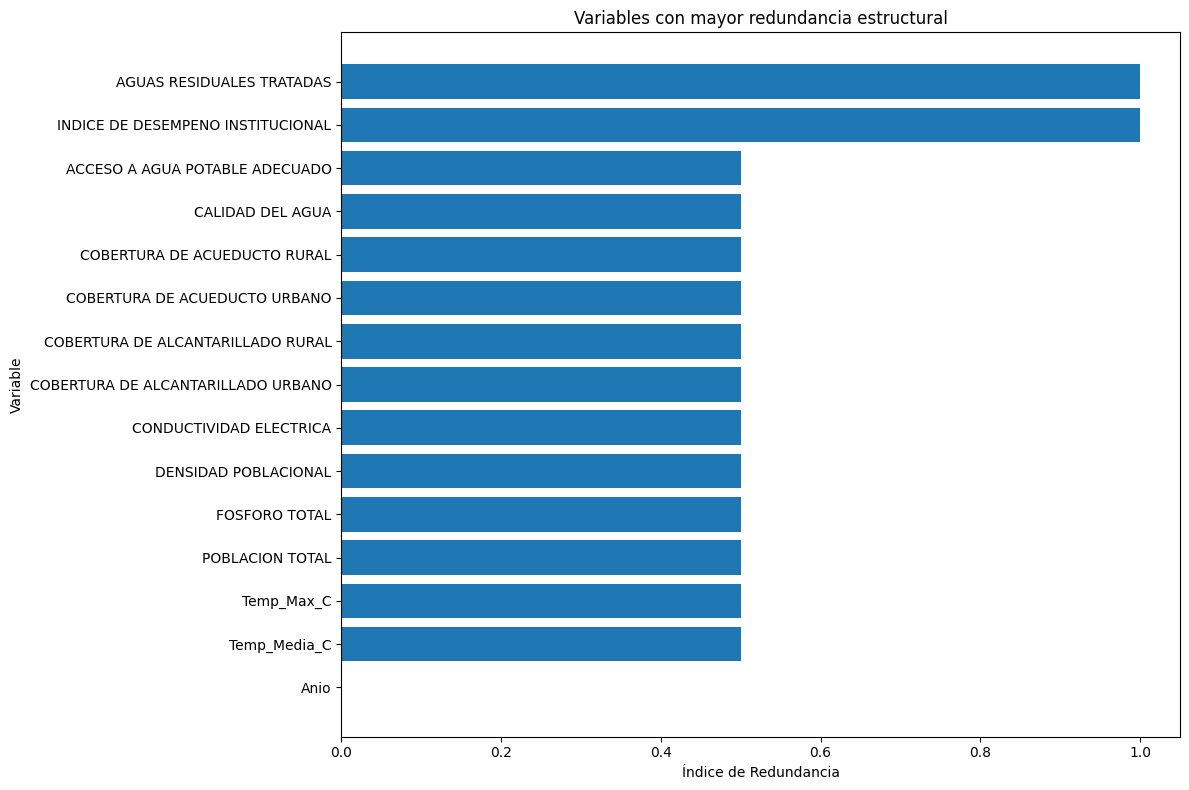

Gráfico de ranking generado correctamente.


In [96]:
#==========================================================
# RANKING GRÁFICO
#==========================================================

plt.figure(figsize=(12, 8))

datos = ranking_redundancia.head(15)

plt.barh(
    datos["Variable"],
    datos["Indice_Redundancia"]
)

plt.gca().invert_yaxis()

plt.xlabel("Índice de Redundancia")
plt.ylabel("Variable")

plt.title(
    "Variables con mayor redundancia estructural"
)

plt.tight_layout()

plt.savefig(
    CARPETA_SALIDA / "ranking_redundancia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Gráfico de ranking generado correctamente.")


RED DE REDUNDANCIA ESTRUCTURAL

Nodos : 14
Aristas: 8


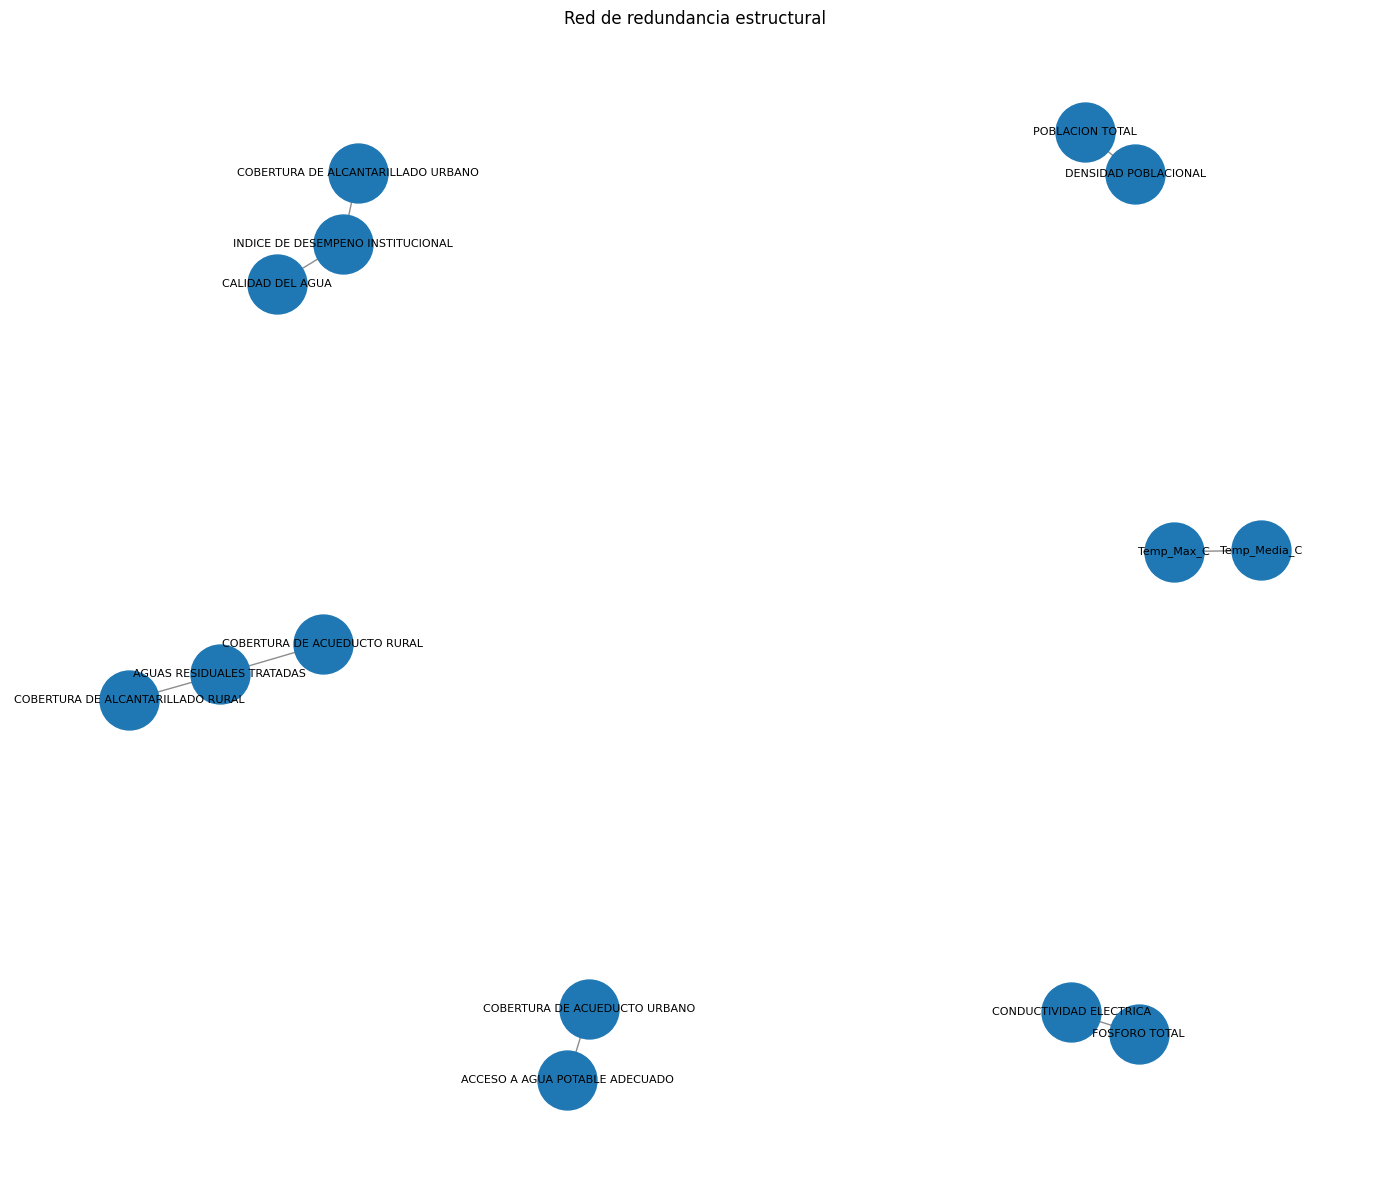

Red de redundancia generada correctamente.


In [97]:
#==========================================================
# RED DE REDUNDANCIA
#==========================================================

G = nx.Graph()

for _, fila in redundantes.iterrows():

    G.add_edge(
        fila["Variable_1"],
        fila["Variable_2"],
        Pearson=fila["Pearson"],
        N_Par=fila["N_Par"]
    )


print()
print("=" * 90)
print("RED DE REDUNDANCIA ESTRUCTURAL")
print("=" * 90)

print()
print("Nodos :", G.number_of_nodes())
print("Aristas:", G.number_of_edges())


plt.figure(figsize=(14, 12))

pos = nx.spring_layout(
    G,
    seed=42
)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=1800
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.45
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=8
)

plt.title(
    "Red de redundancia estructural"
)

plt.axis("off")
plt.tight_layout()

plt.savefig(
    CARPETA_SALIDA / "red_redundancia.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Red de redundancia generada correctamente.")

In [98]:
#==========================================================
# EXPORTACIÓN
#==========================================================

universo.to_csv(
    CARPETA_SALIDA / "redundancia_variables.csv",
    index=False,
    encoding="utf-8-sig"
)

universo.to_excel(
    CARPETA_SALIDA / "redundancia_variables.xlsx",
    index=False
)

ranking_redundancia.to_csv(
    CARPETA_SALIDA / "ranking_redundancia.csv",
    index=False,
    encoding="utf-8-sig"
)

ranking_redundancia.to_excel(
    CARPETA_SALIDA / "ranking_redundancia.xlsx",
    index=False
)

print("Resultados de redundancia exportados correctamente.")
print("Universo:", universo.shape)
print("Ranking :", ranking_redundancia.shape)

Resultados de redundancia exportados correctamente.
Universo: (35, 6)
Ranking : (35, 7)


In [99]:
#==========================================================
# ÍNDICE DE RESULTADOS
#==========================================================

indice_redundancia = pd.DataFrame({

    "Archivo": [
        "redundancia_variables.csv",
        "redundancia_variables.xlsx",
        "ranking_redundancia.csv",
        "ranking_redundancia.xlsx",
        "ranking_redundancia.png",
        "red_redundancia.png",
        "Informe_Redundancia.md"
    ],

    "Descripcion": [
        "Diagnóstico completo de redundancia por variable",
        "Diagnóstico completo de redundancia por variable",
        "Ranking del Índice de Redundancia",
        "Ranking del Índice de Redundancia",
        "Gráfico del ranking de redundancia",
        "Red de redundancia estructural",
        "Informe técnico del diagnóstico de redundancia"
    ]
})

indice_redundancia.to_csv(
    CARPETA_SALIDA / "indice_resultados.csv",
    index=False,
    encoding="utf-8-sig"
)

indice_redundancia.to_excel(
    CARPETA_SALIDA / "indice_resultados.xlsx",
    index=False
)

print("Índice de resultados exportado correctamente.")
print("Archivos indexados:", len(indice_redundancia))

Índice de resultados exportado correctamente.
Archivos indexados: 7


In [100]:
#==========================================================
# INFORME TÉCNICO DE REDUNDANCIA
#==========================================================

ruta_informe = CARPETA_SALIDA / "Informe_Redundancia.md"

with open(
    ruta_informe,
    "w",
    encoding="utf-8"
) as f:

    f.write("# DIAGNÓSTICO DE REDUNDANCIA ESTRUCTURAL\n\n")

    f.write("## Objetivo\n\n")
    f.write(
        "Cuantificar la redundancia estructural entre las variables "
        "numéricas analíticas del Dataset Maestro V04 como insumo "
        "para etapas posteriores del Framework y para la construcción "
        "del Índice de Pertinencia para Machine Learning (IPML).\n\n"
    )

    f.write("## Criterio metodológico\n\n")
    f.write(
        "Se consideran relaciones de redundancia aquellas asociaciones "
        "con correlación absoluta de Pearson >= 0.90 y con un soporte "
        "mínimo de 30 observaciones pareadas. Las correlaciones con menor "
        "soporte no se utilizan para construir este diagnóstico.\n\n"
    )

    f.write(
        "El Índice de Redundancia se obtiene normalizando el número de "
        "relaciones fuertes de cada variable respecto al máximo observado "
        "en el universo analítico. Por tanto, es un indicador relativo "
        "dentro del Dataset Maestro V04.\n\n"
    )

    f.write("## Resultados generales\n\n")
    f.write(f"- Variables analíticas evaluadas: **{len(universo)}**\n")
    f.write(f"- Relaciones redundantes con soporte suficiente: **{len(redundantes)}**\n")
    f.write(f"- Variables involucradas en alguna relación fuerte: **{(universo['Relaciones_Fuertes'] > 0).sum()}**\n")
    f.write(f"- Máximo de relaciones fuertes observado: **{max_relaciones}**\n\n")

    f.write("## Distribución del Índice de Redundancia\n\n")

    for nivel in ["Muy Alta", "Alta", "Moderada", "Baja", "Muy Baja"]:

        cantidad = (
            universo["Nivel_Redundancia"] == nivel
        ).sum()

        f.write(f"- {nivel}: {cantidad} variables\n")

    f.write("\n")

    f.write("## Variables con mayor redundancia\n\n")

    top = ranking_redundancia.head(10)

    for _, fila in top.iterrows():

        f.write(
            f"- {fila['Variable']} "
            f"(relaciones={fila['Relaciones_Fuertes']}, "
            f"IR={fila['Indice_Redundancia']:.3f}, "
            f"nivel={fila['Nivel_Redundancia']})\n"
        )

    f.write("\n")

    f.write("## Interpretación\n\n")
    f.write(
        "Un Índice de Redundancia elevado indica que una variable participa "
        "en una mayor proporción de las relaciones fuertes identificadas "
        "dentro del universo analítico. Un índice igual a cero indica que "
        "la variable no participa en relaciones que cumplan simultáneamente "
        "el umbral de correlación y el soporte mínimo definidos para este análisis.\n\n"
    )

    f.write(
        "Este resultado no implica que una variable sea irrelevante, ni que "
        "deba ser eliminada automáticamente. La redundancia constituye únicamente "
        "un componente diagnóstico que debe evaluarse posteriormente junto con "
        "otros criterios, incluido el VIF, la cobertura, la calidad de los datos "
        "y el conocimiento del dominio.\n\n"
    )

    f.write("## Conclusión\n\n")
    f.write(
        "El diagnóstico caracteriza la redundancia estructural de las 35 "
        "variables numéricas analíticas sin realizar eliminación automática. "
        "Sus resultados quedan disponibles como insumo para los análisis "
        "posteriores del Framework y para la integración final del IPML.\n"
    )


print("Informe técnico de redundancia generado correctamente.")
print("Archivo:", ruta_informe)

Informe técnico de redundancia generado correctamente.
Archivo: Resultados_EDA/Analisis_Redundancia/Informe_Redundancia.md


In [101]:
#==========================================================
# HALLAZGOS CIENTÍFICOS
#==========================================================

print("=" * 90)
print("HALLAZGOS CIENTÍFICOS")
print("=" * 90)

print()

print("✓ Se evaluaron correctamente las 35 variables numéricas analíticas.")

print("✓ Se identificaron 8 relaciones de redundancia estructural")
print("  con |Pearson| >= 0.90 y soporte mínimo de 30 observaciones.")

print("✓ 14 variables participan en al menos una relación fuerte.")

print("✓ AGUAS RESIDUALES TRATADAS e INDICE DE DESEMPENO INSTITUCIONAL")
print("  presentan el mayor Índice de Redundancia observado (IR = 1.000).")

print("✓ 12 variables presentan redundancia moderada (IR = 0.500).")

print("✓ 21 variables no participan en relaciones fuertes bajo")
print("  los criterios definidos para este diagnóstico (IR = 0.000).")

print("✓ Ninguna variable se elimina automáticamente en esta etapa.")

print("✓ El Índice de Redundancia queda disponible como insumo")
print("  para los análisis posteriores del Framework y del IPML.")

HALLAZGOS CIENTÍFICOS

✓ Se evaluaron correctamente las 35 variables numéricas analíticas.
✓ Se identificaron 8 relaciones de redundancia estructural
  con |Pearson| >= 0.90 y soporte mínimo de 30 observaciones.
✓ 14 variables participan en al menos una relación fuerte.
✓ AGUAS RESIDUALES TRATADAS e INDICE DE DESEMPENO INSTITUCIONAL
  presentan el mayor Índice de Redundancia observado (IR = 1.000).
✓ 12 variables presentan redundancia moderada (IR = 0.500).
✓ 21 variables no participan en relaciones fuertes bajo
  los criterios definidos para este diagnóstico (IR = 0.000).
✓ Ninguna variable se elimina automáticamente en esta etapa.
✓ El Índice de Redundancia queda disponible como insumo
  para los análisis posteriores del Framework y del IPML.


In [102]:
#==========================================================
# CONCLUSIONES
#==========================================================

print()
print("=" * 90)
print("CONCLUSIONES")
print("=" * 90)

print()

print("• El diagnóstico cuantifica la redundancia estructural")
print("  de las 35 variables numéricas analíticas del Dataset Maestro.")

print()

print("• Las relaciones consideradas cumplen simultáneamente")
print("  |Pearson| >= 0.90 y un soporte mínimo de 30 observaciones.")

print()

print("• Ninguna variable es descartada automáticamente en esta etapa.")

print()

print("• El Índice de Redundancia constituye un componente")
print("  diagnóstico para las etapas posteriores del Framework.")

print()

print("• La evaluación final de pertinencia para Machine Learning")
print("  será realizada posteriormente mediante el IPML.")


CONCLUSIONES

• El diagnóstico cuantifica la redundancia estructural
  de las 35 variables numéricas analíticas del Dataset Maestro.

• Las relaciones consideradas cumplen simultáneamente
  |Pearson| >= 0.90 y un soporte mínimo de 30 observaciones.

• Ninguna variable es descartada automáticamente en esta etapa.

• El Índice de Redundancia constituye un componente
  diagnóstico para las etapas posteriores del Framework.

• La evaluación final de pertinencia para Machine Learning
  será realizada posteriormente mediante el IPML.


#### **Diagnóstico de Multicolinealidad mediante VIF**

**¿Qué es el VIF?**

Supongamos una variable:
**Precipitación**

Ahora intentamos explicarla usando TODAS las demás variables.

Si la precipitación puede predecirse casi perfectamente mediante las demás variables:
Entonces... **no aporta mucha información nueva.**

Eso es exactamente lo que mide el VIF.

**Matemáticamente:**

$$VIF_i = \frac{1}{1 - R_i^2}$$

Donde:
* $R_i^2$ es el coeficiente de determinación obtenido al usar la variable $i$ como variable dependiente y todas las demás como predictoras.

Interpretación

| VIF  | Interpretación        |
| ---- | --------------------- |
| 1    | Sin multicolinealidad |
| 1–5  | Baja                  |
| 5–10 | Moderada              |
| >10  | Alta                  |
| >20  | Muy alta              |

No eliminaremos variables únicamente por tener un VIF alto. El VIF será uno de los componentes del IPML, no una regla absoluta.

---

A diferencia del proceso anterior, donde la redundancia se evaluó mediante correlaciones fuertes, el proceso a continuación cuantifica la multicolinealidad, es decir, el grado en que una variable puede ser explicada por la combinación simultánea de todas las demás variables del conjunto de datos.

Este análisis es especialmente relevante para modelos lineales y constituye uno de los criterios objetivos que alimentarán el cálculo del IPML.

In [103]:
#==========================================================
# CONFIGURACIÓN - DIAGNÓSTICO VIF
#==========================================================

from statsmodels.stats.outliers_influence import variance_inflation_factor

RUTA_DATASET = (
    "https://raw.githubusercontent.com/jriatiga/FRAMEWORK_V7/"
    "refs/heads/main/DATA/MASTER/C09_MASTER/"
    "Dataset_Maestro_Framework_v04.parquet"
)

RUTA_UNIVERSO = (
    "Resultados_EDA/Analisis_Redundancia/"
    "redundancia_variables.csv"
)

CARPETA_SALIDA = Path(
    "Resultados_EDA/Analisis_Multicolinealidad"
)

CARPETA_SALIDA.mkdir(
    parents=True,
    exist_ok=True
)

print("Configuración VIF preparada.")
print("Universo :", RUTA_UNIVERSO)
print("Salida   :", CARPETA_SALIDA)

Configuración VIF preparada.
Universo : Resultados_EDA/Analisis_Redundancia/redundancia_variables.csv
Salida   : Resultados_EDA/Analisis_Multicolinealidad


In [104]:
#==========================================================
# CARGA DE INFORMACIÓN
#==========================================================

dataset = pd.read_parquet(RUTA_DATASET)
universo = pd.read_csv(RUTA_UNIVERSO)

print()
print("=" * 90)
print("DIAGNÓSTICO DE MULTICOLINEALIDAD MEDIANTE VIF")
print("=" * 90)

print()
print(f"Observaciones       : {dataset.shape[0]:,}")
print(f"Variables Dataset   : {dataset.shape[1]}")
print(f"Variables evaluadas : {len(universo)}")


DIAGNÓSTICO DE MULTICOLINEALIDAD MEDIANTE VIF

Observaciones       : 528
Variables Dataset   : 52
Variables evaluadas : 35


In [105]:
#==========================================================
# VALIDACIÓN DEL UNIVERSO ANALÍTICO
#==========================================================

columnas_requeridas = [
    "Variable",
    "Indice_Redundancia",
    "Nivel_Redundancia"
]

faltantes = [
    c
    for c in columnas_requeridas
    if c not in universo.columns
]

if len(faltantes) > 0:
    raise Exception(
        f"Faltan columnas requeridas: {faltantes}"
    )

print()
print("=" * 90)
print("VALIDACIÓN DEL UNIVERSO ANALÍTICO")
print("=" * 90)

print()
print("Universo Analítico cargado correctamente.")
print("Filas    :", len(universo))
print("Columnas :", universo.columns.tolist())


VALIDACIÓN DEL UNIVERSO ANALÍTICO

Universo Analítico cargado correctamente.
Filas    : 35
Columnas : ['Variable', 'Tipo', 'Relaciones_Fuertes', 'Indice_Redundancia', 'Nivel_Redundancia', 'Observacion']


In [106]:
#==========================================================
# MATRIZ NUMÉRICA PARA EL CÁLCULO DEL VIF
#==========================================================

variables_modelo = universo["Variable"].tolist()

faltantes_dataset = [
    v for v in variables_modelo
    if v not in dataset.columns
]

if faltantes_dataset:
    raise Exception(
        f"Variables del universo ausentes en el Dataset Maestro: {faltantes_dataset}"
    )

X = dataset[variables_modelo].copy()

print()
print("=" * 90)
print("MATRIZ PARA VIF")
print("=" * 90)

print()
print(f"Variables utilizadas : {X.shape[1]}")
print(f"Observaciones         : {X.shape[0]}")

print()
print("Valores faltantes antes de imputación:")
print(X.isna().sum().sum())


MATRIZ PARA VIF

Variables utilizadas : 35
Observaciones         : 528

Valores faltantes antes de imputación:
7252


In [107]:
#==========================================================
# DIAGNÓSTICO DE VARIABLES CONSTANTES
#==========================================================

constantes = []

for columna in X.columns:

    n_unicos = X[columna].nunique(dropna=True)

    if n_unicos <= 1:
        constantes.append(columna)

print()
print("=" * 90)
print("DIAGNÓSTICO DE VARIABLES CONSTANTES")
print("=" * 90)

print()
print(f"Variables constantes encontradas : {len(constantes)}")

if constantes:
    print()
    for c in constantes:
        print("-", c)


DIAGNÓSTICO DE VARIABLES CONSTANTES

Variables constantes encontradas : 1

- CONTINUIDAD DE ACUEDUCTO URBANO


In [108]:
#==========================================================
# EXCLUSIÓN DE VARIABLES CONSTANTES PARA VIF
#==========================================================

X_vif = X.drop(
    columns=constantes,
    errors="ignore"
).copy()

print()
print("=" * 90)
print("MATRIZ AJUSTADA PARA VIF")
print("=" * 90)

print()
print("Variables excluidas :", constantes)
print("Variables restantes :", X_vif.shape[1])
print("Observaciones       :", X_vif.shape[0])


MATRIZ AJUSTADA PARA VIF

Variables excluidas : ['CONTINUIDAD DE ACUEDUCTO URBANO']
Variables restantes : 34
Observaciones       : 528


In [109]:
#==========================================================
# IMPUTACIÓN POR MEDIANA EXCLUSIVA PARA EL CÁLCULO DEL VIF
#==========================================================

faltantes_antes_vif = X_vif.isna().sum().sum()

for columna in X_vif.columns:

    X_vif[columna] = (
        X_vif[columna]
        .fillna(
            X_vif[columna].median()
        )
    )

faltantes_despues_vif = X_vif.isna().sum().sum()

print()
print("=" * 90)
print("IMPUTACIÓN PARA VIF FINALIZADA")
print("=" * 90)

print()
print("Valores faltantes antes :", faltantes_antes_vif)
print("Valores faltantes después:", faltantes_despues_vif)
print("Matriz final            :", X_vif.shape)


IMPUTACIÓN PARA VIF FINALIZADA

Valores faltantes antes : 6820
Valores faltantes después: 0
Matriz final            : (528, 34)


In [110]:
#==========================================================
# CÁLCULO DEL VIF
#==========================================================

vif = pd.DataFrame({
    "Variable": X_vif.columns
})

vif["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

vif["VIF"] = vif["VIF"].round(3)

vif_ordenado = (
    vif
    .sort_values(
        by="VIF",
        ascending=False
    )
    .reset_index(drop=True)
)

print()
print("=" * 90)
print("FACTOR DE INFLACIÓN DE LA VARIANZA")
print("=" * 90)

print()
print("Variables con VIF calculado:", len(vif))
print("VIF infinitos              :", np.isinf(vif["VIF"]).sum())

display(vif_ordenado.head(15))


FACTOR DE INFLACIÓN DE LA VARIANZA

Variables con VIF calculado: 34
VIF infinitos              : 0


,Variable,VIF
0,COBERTURA DE ACUEDUCTO URBANO,1370719.577
1,Anio,1144249.052
2,ACCESO A AGUA POTABLE ADECUADO,8106.785
3,pH,5933.192
4,COBERTURA DE ACUEDUCTO RURAL,5005.617
5,Temp_Media_C,4553.428
6,INDICE DE DESEMPENO INSTITUCIONAL,3002.172
7,POBLACION TOTAL,2765.329
8,Temp_Max_C,2675.040
9,DENSIDAD POBLACIONAL,2621.295


In [111]:
#==========================================================
# CÁLCULO CORREGIDO DEL VIF CON INTERCEPTO
#==========================================================

from statsmodels.tools.tools import add_constant

# Agregar intercepto a la matriz de diseño
X_vif_const = add_constant(
    X_vif,
    has_constant="add"
)

vif = pd.DataFrame({
    "Variable": X_vif.columns
})

vif["VIF"] = [
    variance_inflation_factor(
        X_vif_const.values,
        i
    )
    for i in range(1, X_vif_const.shape[1])  # excluir const
]

vif["VIF"] = vif["VIF"].round(3)

vif_ordenado = (
    vif
    .sort_values(
        by="VIF",
        ascending=False
    )
    .reset_index(drop=True)
)

print()
print("=" * 90)
print("FACTOR DE INFLACIÓN DE LA VARIANZA - CÁLCULO CORREGIDO")
print("=" * 90)

print()
print("Variables con VIF calculado:", len(vif))
print("VIF infinitos              :", np.isinf(vif["VIF"]).sum())

display(vif_ordenado.head(15))


FACTOR DE INFLACIÓN DE LA VARIANZA - CÁLCULO CORREGIDO

Variables con VIF calculado: 34
VIF infinitos              : 0


,Variable,VIF
0,DENSIDAD POBLACIONAL,1329.161
1,POBLACION TOTAL,1182.398
2,Temp_Media_C,82.340
3,COBERTURA DE ACUEDUCTO URBANO,42.952
4,ACCESO A AGUA POTABLE ADECUADO,37.091
5,Temp_Max_C,36.388
6,COBERTURA DE ACUEDUCTO RURAL,32.439
7,CONDUCTIVIDAD ELECTRICA,22.148
8,FOSFORO TOTAL,14.559
9,Temp_Min_C,13.221


In [112]:
#==========================================================
# CLASIFICACIÓN DEL VIF
#==========================================================

def clasificar_vif(v):

    if pd.isna(v):
        return "No Calculado"

    elif np.isinf(v):
        return "Perfecta"

    elif v >= 20:
        return "Muy Alta"

    elif v >= 10:
        return "Alta"

    elif v >= 5:
        return "Moderada"

    elif v > 1:
        return "Baja"

    else:
        return "Sin Multicolinealidad"


vif["Estado_VIF"] = vif["VIF"].apply(clasificar_vif)

vif_ordenado = (
    vif
    .sort_values(
        by="VIF",
        ascending=False
    )
    .reset_index(drop=True)
)

print()
print("=" * 90)
print("CLASIFICACIÓN DEL VIF")
print("=" * 90)

print()
print("Distribución:")
print(vif["Estado_VIF"].value_counts())

print()
display(vif_ordenado.head(15))


CLASIFICACIÓN DEL VIF

Distribución:
Estado_VIF
Baja        17
Muy Alta     8
Moderada     6
Alta         3
Name: count, dtype: int64



,Variable,VIF,Estado_VIF
0,DENSIDAD POBLACIONAL,1329.161,Muy Alta
1,POBLACION TOTAL,1182.398,Muy Alta
2,Temp_Media_C,82.340,Muy Alta
3,COBERTURA DE ACUEDUCTO URBANO,42.952,Muy Alta
4,ACCESO A AGUA POTABLE ADECUADO,37.091,Muy Alta
5,Temp_Max_C,36.388,Muy Alta
6,COBERTURA DE ACUEDUCTO RURAL,32.439,Muy Alta
7,CONDUCTIVIDAD ELECTRICA,22.148,Muy Alta
8,FOSFORO TOTAL,14.559,Alta
9,Temp_Min_C,13.221,Alta


In [113]:
#==========================================================
# INTEGRACIÓN DEL VIF AL UNIVERSO ANALÍTICO
#==========================================================

def diagnostico_vif(estado):

    diagnosticos = {

        "Perfecta":
        "Se detecta colinealidad lineal perfecta con el conjunto de variables.",

        "Muy Alta":
        "Se detecta multicolinealidad muy alta respecto al conjunto de variables.",

        "Alta":
        "Se detecta multicolinealidad alta respecto al conjunto de variables.",

        "Moderada":
        "Se detecta multicolinealidad moderada respecto al conjunto de variables.",

        "Baja":
        "Se detecta baja multicolinealidad respecto al conjunto de variables.",

        "Sin Multicolinealidad":
        "No se detecta inflación relevante de varianza bajo este criterio.",

        "No Calculado":
        "VIF no calculable por varianza nula de la variable."
    }

    return diagnosticos.get(estado, "")


# Evitar duplicados si la celda se ejecuta nuevamente
universo = universo.drop(
    columns=["VIF", "Estado_VIF", "Diagnostico_VIF"],
    errors="ignore"
)

# Integrar los 34 VIF calculados
universo = universo.merge(
    vif[["Variable", "VIF", "Estado_VIF"]],
    on="Variable",
    how="left"
)

# Identificar explícitamente las variables constantes
mascara_constantes = universo["Variable"].isin(constantes)

universo.loc[
    mascara_constantes,
    "VIF"
] = np.nan

universo.loc[
    mascara_constantes,
    "Estado_VIF"
] = "No Calculado"

# Diagnóstico textual
universo["Diagnostico_VIF"] = (
    universo["Estado_VIF"]
    .apply(diagnostico_vif)
)

print()
print("=" * 90)
print("INTEGRACIÓN DEL VIF AL UNIVERSO ANALÍTICO")
print("=" * 90)

print()
print("Variables del universo :", len(universo))
print("VIF calculados         :", universo["VIF"].notna().sum())
print("VIF no calculados      :", universo["VIF"].isna().sum())

print()
print("Distribución:")
print(universo["Estado_VIF"].value_counts(dropna=False))

print()
display(
    universo[
        universo["Estado_VIF"] == "No Calculado"
    ][
        ["Variable", "VIF", "Estado_VIF", "Diagnostico_VIF"]
    ]
)


INTEGRACIÓN DEL VIF AL UNIVERSO ANALÍTICO

Variables del universo : 35
VIF calculados         : 34
VIF no calculados      : 1

Distribución:
Estado_VIF
Baja            17
Muy Alta         8
Moderada         6
Alta             3
No Calculado     1
Name: count, dtype: int64



,Variable,VIF,Estado_VIF,Diagnostico_VIF
21,CONTINUIDAD DE ACUEDUCTO URBANO,NaN,No Calculado,VIF no calculable por varianza nula de la vari...


In [114]:
#==========================================================
# DIAGNÓSTICO TEXTUAL DE REDUNDANCIA
#==========================================================

def diagnostico_redundancia(nivel):

    diagnosticos = {

        "Muy Alta":
        "Participa en el máximo relativo de relaciones fuertes detectadas.",

        "Alta":
        "Participa en un nivel alto de relaciones fuertes detectadas.",

        "Moderada":
        "Participa en un nivel intermedio de relaciones fuertes detectadas.",

        "Baja":
        "Participa en un nivel bajo de relaciones fuertes detectadas.",

        "Muy Baja":
        "No presenta relaciones fuertes bajo el criterio definido."
    }

    return diagnosticos.get(nivel, "")


# Sustituir la columna vacía heredada de M7
universo = universo.rename(
    columns={
        "Observacion": "Diagnostico_Redundancia"
    }
)

universo["Diagnostico_Redundancia"] = (
    universo["Nivel_Redundancia"]
    .apply(diagnostico_redundancia)
)

print()
print("=" * 90)
print("DIAGNÓSTICO DE REDUNDANCIA INTEGRADO")
print("=" * 90)

print()
print("Variables:", len(universo))
print(universo["Nivel_Redundancia"].value_counts())

print()
display(
    universo[
        [
            "Variable",
            "Relaciones_Fuertes",
            "Indice_Redundancia",
            "Nivel_Redundancia",
            "Diagnostico_Redundancia"
        ]
    ].head()
)


DIAGNÓSTICO DE REDUNDANCIA INTEGRADO

Variables: 35
Nivel_Redundancia
Muy Baja    21
Moderada    12
Muy Alta     2
Name: count, dtype: int64



,Variable,Relaciones_Fuertes,Indice_Redundancia,Nivel_Redundancia,Diagnostico_Redundancia
0,Precipitacion_mm,0,0.0,Muy Baja,No presenta relaciones fuertes bajo el criteri...
1,Temp_Max_C,1,0.5,Moderada,Participa en un nivel intermedio de relaciones...
2,Temp_Min_C,0,0.0,Muy Baja,No presenta relaciones fuertes bajo el criteri...
3,Temp_Media_C,1,0.5,Moderada,Participa en un nivel intermedio de relaciones...
4,Humedad_Relativa,0,0.0,Muy Baja,No presenta relaciones fuertes bajo el criteri...


In [115]:
#==========================================================
# RECOMENDACIÓN TÉCNICA SEGÚN VIF
#==========================================================

def recomendacion_vif(estado):

    recomendaciones = {

        "Perfecta":
        "Revisar colinealidad perfecta antes de etapas posteriores.",

        "Muy Alta":
        "Revisar multicolinealidad muy alta en conjunto con los demás criterios.",

        "Alta":
        "Considerar la dependencia lineal en la evaluación posterior.",

        "Moderada":
        "Mantener bajo observación dentro de la evaluación multivariable.",

        "Baja":
        "Sin señal crítica de multicolinealidad bajo este criterio.",

        "Sin Multicolinealidad":
        "Sin señal relevante de multicolinealidad bajo este criterio.",

        "No Calculado":
        "Evaluar por separado debido a varianza nula; el VIF no es calculable."
    }

    return recomendaciones.get(estado, "")


universo["Recomendacion_VIF"] = (
    universo["Estado_VIF"]
    .apply(recomendacion_vif)
)

print()
print("=" * 90)
print("RECOMENDACIONES VIF INTEGRADAS")
print("=" * 90)

print()
print("Variables:", len(universo))
print("Recomendaciones vacías:", (universo["Recomendacion_VIF"] == "").sum())

print()
display(
    universo[
        [
            "Variable",
            "VIF",
            "Estado_VIF",
            "Diagnostico_VIF",
            "Recomendacion_VIF"
        ]
    ].head()
)

print()
display(
    universo.loc[
        universo["Estado_VIF"] == "No Calculado",
        [
            "Variable",
            "VIF",
            "Estado_VIF",
            "Recomendacion_VIF"
        ]
    ]
)


RECOMENDACIONES VIF INTEGRADAS

Variables: 35
Recomendaciones vacías: 0



,Variable,VIF,Estado_VIF,Diagnostico_VIF,Recomendacion_VIF
0,Precipitacion_mm,1.990,Baja,Se detecta baja multicolinealidad respecto al ...,Sin señal crítica de multicolinealidad bajo es...
1,Temp_Max_C,36.388,Muy Alta,Se detecta multicolinealidad muy alta respecto...,Revisar multicolinealidad muy alta en conjunto...
2,Temp_Min_C,13.221,Alta,Se detecta multicolinealidad alta respecto al ...,Considerar la dependencia lineal en la evaluac...
3,Temp_Media_C,82.340,Muy Alta,Se detecta multicolinealidad muy alta respecto...,Revisar multicolinealidad muy alta en conjunto...
4,Humedad_Relativa,9.391,Moderada,Se detecta multicolinealidad moderada respecto...,Mantener bajo observación dentro de la evaluac...


,Variable,VIF,Estado_VIF,Recomendacion_VIF
21,CONTINUIDAD DE ACUEDUCTO URBANO,NaN,No Calculado,Evaluar por separado debido a varianza nula; e...


In [116]:
#==========================================================
# EXPORTACIÓN DEL UNIVERSO ANALÍTICO CON VIF
#==========================================================

ruta_csv_vif = CARPETA_SALIDA / "universo_analitico_vif.csv"
ruta_xlsx_vif = CARPETA_SALIDA / "universo_analitico_vif.xlsx"

universo.to_csv(
    ruta_csv_vif,
    index=False,
    encoding="utf-8-sig"
)

universo.to_excel(
    ruta_xlsx_vif,
    index=False
)

print()
print("=" * 90)
print("UNIVERSO ANALÍTICO VIF EXPORTADO")
print("=" * 90)

print()
print("Dimensión :", universo.shape)
print("Variables únicas:", universo["Variable"].nunique())
print("CSV  :", ruta_csv_vif)
print("XLSX :", ruta_xlsx_vif)


UNIVERSO ANALÍTICO VIF EXPORTADO

Dimensión : (35, 10)
Variables únicas: 35
CSV  : Resultados_EDA/Analisis_Multicolinealidad/universo_analitico_vif.csv
XLSX : Resultados_EDA/Analisis_Multicolinealidad/universo_analitico_vif.xlsx


In [117]:
#==========================================================
# RANKING DE MULTICOLINEALIDAD SEGÚN VIF
#==========================================================

ranking_vif = (
    universo
    .sort_values(
        by=["VIF", "Variable"],
        ascending=[False, True],
        na_position="last"
    )
    .reset_index(drop=True)
)

ranking_vif.insert(
    0,
    "Ranking_VIF",
    np.arange(1, len(ranking_vif) + 1)
)

ruta_ranking_csv = CARPETA_SALIDA / "ranking_vif.csv"
ruta_ranking_xlsx = CARPETA_SALIDA / "ranking_vif.xlsx"

ranking_vif.to_csv(
    ruta_ranking_csv,
    index=False,
    encoding="utf-8-sig"
)

ranking_vif.to_excel(
    ruta_ranking_xlsx,
    index=False
)

print()
print("=" * 90)
print("RANKING VIF GENERADO")
print("=" * 90)

print()
print("Filas :", len(ranking_vif))
print("CSV   :", ruta_ranking_csv)
print("XLSX  :", ruta_ranking_xlsx)

print()
display(
    ranking_vif[
        [
            "Ranking_VIF",
            "Variable",
            "VIF",
            "Estado_VIF"
        ]
    ].head(15)
)

print()
print("Última variable del ranking:")
display(
    ranking_vif[
        [
            "Ranking_VIF",
            "Variable",
            "VIF",
            "Estado_VIF"
        ]
    ].tail(1)
)


RANKING VIF GENERADO

Filas : 35
CSV   : Resultados_EDA/Analisis_Multicolinealidad/ranking_vif.csv
XLSX  : Resultados_EDA/Analisis_Multicolinealidad/ranking_vif.xlsx



,Ranking_VIF,Variable,VIF,Estado_VIF
0,1,DENSIDAD POBLACIONAL,1329.161,Muy Alta
1,2,POBLACION TOTAL,1182.398,Muy Alta
2,3,Temp_Media_C,82.340,Muy Alta
3,4,COBERTURA DE ACUEDUCTO URBANO,42.952,Muy Alta
4,5,ACCESO A AGUA POTABLE ADECUADO,37.091,Muy Alta
5,6,Temp_Max_C,36.388,Muy Alta
6,7,COBERTURA DE ACUEDUCTO RURAL,32.439,Muy Alta
7,8,CONDUCTIVIDAD ELECTRICA,22.148,Muy Alta
8,9,FOSFORO TOTAL,14.559,Alta
9,10,Temp_Min_C,13.221,Alta



Última variable del ranking:


,Ranking_VIF,Variable,VIF,Estado_VIF
34,35,CONTINUIDAD DE ACUEDUCTO URBANO,NaN,No Calculado


In [118]:
#==========================================================
# RESUMEN EJECUTIVO DEL DIAGNÓSTICO VIF
#==========================================================

conteo_vif = universo["Estado_VIF"].value_counts()

print()
print("=" * 90)
print("RESUMEN EJECUTIVO - MULTICOLINEALIDAD VIF")
print("=" * 90)

print()
print(f"Variables del universo        : {len(universo)}")
print(f"VIF calculados                : {universo['VIF'].notna().sum()}")
print(f"VIF no calculados             : {universo['VIF'].isna().sum()}")

print()
print("Distribución por nivel:")

for estado in [
    "Perfecta",
    "Muy Alta",
    "Alta",
    "Moderada",
    "Baja",
    "Sin Multicolinealidad",
    "No Calculado"
]:
    print(
        f"{estado:<24}: "
        f"{conteo_vif.get(estado, 0)}"
    )

print()
print("Mayor VIF calculado:")
print(
    ranking_vif.loc[
        ranking_vif["VIF"].notna(),
        ["Variable", "VIF", "Estado_VIF"]
    ].head(1).to_string(index=False)
)


RESUMEN EJECUTIVO - MULTICOLINEALIDAD VIF

Variables del universo        : 35
VIF calculados                : 34
VIF no calculados             : 1

Distribución por nivel:
Perfecta                : 0
Muy Alta                : 8
Alta                    : 3
Moderada                : 6
Baja                    : 17
Sin Multicolinealidad   : 0
No Calculado            : 1

Mayor VIF calculado:
            Variable      VIF Estado_VIF
DENSIDAD POBLACIONAL 1329.161   Muy Alta


In [119]:
#==========================================================
# INFORME TÉCNICO DEL DIAGNÓSTICO VIF
#==========================================================

from datetime import datetime

fecha = datetime.now().strftime("%Y-%m-%d %H:%M")

n_variables = len(universo)
n_calculados = universo["VIF"].notna().sum()
n_no_calculados = universo["VIF"].isna().sum()

perfecta = (universo["Estado_VIF"] == "Perfecta").sum()
muy_alta = (universo["Estado_VIF"] == "Muy Alta").sum()
alta = (universo["Estado_VIF"] == "Alta").sum()
moderada = (universo["Estado_VIF"] == "Moderada").sum()
baja = (universo["Estado_VIF"] == "Baja").sum()
sin_multi = (
    universo["Estado_VIF"] == "Sin Multicolinealidad"
).sum()
no_calculado = (
    universo["Estado_VIF"] == "No Calculado"
).sum()

top_vif = (
    ranking_vif[
        ranking_vif["VIF"].notna()
    ][
        ["Variable", "VIF", "Estado_VIF"]
    ]
    .head(10)
)

ruta_informe_vif = CARPETA_SALIDA / "Informe_VIF.md"

with open(
    ruta_informe_vif,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "# INFORME TÉCNICO DEL ANÁLISIS "
        "DE MULTICOLINEALIDAD MEDIANTE VIF\n\n"
    )

    f.write(f"Fecha de ejecución: {fecha}\n\n")

    #------------------------------------------------------
    # OBJETIVO
    #------------------------------------------------------

    f.write("## 1. Objetivo\n\n")

    f.write(
        "Evaluar la multicolinealidad del universo analítico "
        "numérico mediante el Factor de Inflación de la "
        "Varianza (VIF), como diagnóstico complementario "
        "al análisis de redundancia estructural realizado "
        "previamente.\n\n"
    )

    #------------------------------------------------------
    # METODOLOGÍA
    #------------------------------------------------------

    f.write("## 2. Metodología\n\n")

    f.write(
        f"- Universo analítico inicial: **{n_variables} variables**.\n"
    )

    f.write(
        "- Se excluyeron del cálculo matemático del VIF las "
        "variables con varianza nula.\n"
    )

    f.write(
        "- Los valores faltantes se imputaron temporalmente "
        "mediante la mediana exclusivamente para permitir "
        "el cálculo del VIF.\n"
    )

    f.write(
        "- Esta imputación auxiliar no modifica el Dataset "
        "Maestro V04.\n"
    )

    f.write(
        "- Las regresiones auxiliares utilizadas para el VIF "
        "incluyeron explícitamente un intercepto.\n"
    )

    f.write(
        "- La constante utilizada como intercepto no forma "
        "parte del universo analítico.\n\n"
    )

    f.write("### Clasificación utilizada\n\n")

    f.write("| VIF | Estado |\n")
    f.write("|---:|---|\n")
    f.write("| ≤ 1 | Sin Multicolinealidad |\n")
    f.write("| > 1 y < 5 | Baja |\n")
    f.write("| ≥ 5 y < 10 | Moderada |\n")
    f.write("| ≥ 10 y < 20 | Alta |\n")
    f.write("| ≥ 20 | Muy Alta |\n")
    f.write("| ∞ | Perfecta |\n\n")

    #------------------------------------------------------
    # RESULTADOS
    #------------------------------------------------------

    f.write("## 3. Resultados\n\n")

    f.write(
        f"- Variables del universo: **{n_variables}**\n"
    )
    f.write(
        f"- Variables con VIF calculado: **{n_calculados}**\n"
    )
    f.write(
        f"- Variables con VIF no calculado: "
        f"**{n_no_calculados}**\n"
    )
    f.write(
        f"- Multicolinealidad perfecta: **{perfecta}**\n"
    )
    f.write(
        f"- Muy alta: **{muy_alta}**\n"
    )
    f.write(
        f"- Alta: **{alta}**\n"
    )
    f.write(
        f"- Moderada: **{moderada}**\n"
    )
    f.write(
        f"- Baja: **{baja}**\n"
    )
    f.write(
        f"- Sin multicolinealidad: **{sin_multi}**\n"
    )
    f.write(
        f"- No calculado: **{no_calculado}**\n\n"
    )

    #------------------------------------------------------
    # TOP VIF
    #------------------------------------------------------

    f.write("## 4. Variables con mayor VIF\n\n")

    f.write(
        top_vif.to_markdown(
            index=False
        )
    )

    f.write("\n\n")

    #------------------------------------------------------
    # VARIABLE CONSTANTE
    #------------------------------------------------------

    f.write("## 5. Variables con VIF no calculable\n\n")

    for variable in constantes:
        f.write(
            f"- **{variable}**: VIF no calculable por "
            "varianza nula.\n"
        )

    f.write("\n")

    #------------------------------------------------------
    # INTERPRETACIÓN
    #------------------------------------------------------

    f.write("## 6. Interpretación\n\n")

    f.write(
        "El diagnóstico evidencia distintos niveles de "
        "dependencia lineal multivariable dentro del universo "
        "analítico. Los valores elevados de VIF indican que "
        "parte de la variabilidad de determinadas variables "
        "puede ser explicada por combinaciones lineales de "
        "otras variables del conjunto.\n\n"
    )

    f.write(
        "El VIF y el Índice de Redundancia no representan "
        "el mismo fenómeno: el primero evalúa dependencia "
        "lineal multivariable, mientras que el segundo resume "
        "las relaciones bivariadas fuertes que cumplen el "
        "criterio establecido en el análisis previo.\n\n"
    )

    #------------------------------------------------------
    # LIMITACIONES
    #------------------------------------------------------

    f.write("## 7. Consideraciones metodológicas\n\n")

    f.write(
        "- El VIF fue calculado sobre una matriz auxiliar "
        "completada mediante imputación por mediana.\n"
    )

    f.write(
        "- Las variables con baja cobertura original deben "
        "interpretarse conjuntamente con el diagnóstico de "
        "calidad y disponibilidad de datos.\n"
    )

    f.write(
        "- Un VIF elevado no implica eliminación automática "
        "de una variable.\n"
    )

    f.write(
        "- La variable con varianza nula permanece dentro "
        "del universo analítico con estado `No Calculado`.\n"
    )

    f.write(
        "- Estos resultados constituyen evidencia diagnóstica "
        "que será integrada posteriormente con otros criterios "
        "en el IPML.\n\n"
    )

    #------------------------------------------------------
    # CONCLUSIÓN
    #------------------------------------------------------

    f.write("## 8. Conclusión\n\n")

    f.write(
        "El análisis VIF proporciona una medida complementaria "
        "de multicolinealidad para las variables del Dataset "
        "Maestro V04. Sus resultados se conservan como insumo "
        "del Framework y no constituyen, por sí solos, una "
        "decisión de selección o descarte de variables.\n"
    )

print()
print("=" * 90)
print("INFORME TÉCNICO VIF GENERADO")
print("=" * 90)

print()
print("Archivo :", ruta_informe_vif)
print("Existe  :", ruta_informe_vif.exists())


INFORME TÉCNICO VIF GENERADO

Archivo : Resultados_EDA/Analisis_Multicolinealidad/Informe_VIF.md
Existe  : True


In [120]:
#==========================================================
# ÍNDICE DE RESULTADOS DEL ANÁLISIS VIF
#==========================================================

indice_vif = pd.DataFrame({

    "Archivo": [
        "universo_analitico_vif.csv",
        "universo_analitico_vif.xlsx",
        "ranking_vif.csv",
        "ranking_vif.xlsx",
        "Informe_VIF.md"
    ],

    "Descripcion": [
        "Universo analítico enriquecido con diagnóstico VIF.",
        "Universo analítico enriquecido con diagnóstico VIF (Excel).",
        "Ranking de variables según Factor de Inflación de la Varianza.",
        "Ranking de variables según VIF (Excel).",
        "Informe técnico del diagnóstico de multicolinealidad."
    ]
})

ruta_indice_csv = CARPETA_SALIDA / "indice_resultados.csv"
ruta_indice_xlsx = CARPETA_SALIDA / "indice_resultados.xlsx"

indice_vif.to_csv(
    ruta_indice_csv,
    index=False,
    encoding="utf-8-sig"
)

indice_vif.to_excel(
    ruta_indice_xlsx,
    index=False
)

print()
print("=" * 90)
print("ÍNDICE DE RESULTADOS VIF")
print("=" * 90)

print()
print("Artefactos indexados :", len(indice_vif))
print("CSV  :", ruta_indice_csv)
print("XLSX :", ruta_indice_xlsx)

print()
display(indice_vif)


ÍNDICE DE RESULTADOS VIF

Artefactos indexados : 5
CSV  : Resultados_EDA/Analisis_Multicolinealidad/indice_resultados.csv
XLSX : Resultados_EDA/Analisis_Multicolinealidad/indice_resultados.xlsx



,Archivo,Descripcion
0,universo_analitico_vif.csv,Universo analítico enriquecido con diagnóstico...
1,universo_analitico_vif.xlsx,Universo analítico enriquecido con diagnóstico...
2,ranking_vif.csv,Ranking de variables según Factor de Inflación...
3,ranking_vif.xlsx,Ranking de variables según VIF (Excel).
4,Informe_VIF.md,Informe técnico del diagnóstico de multicoline...


### **Catalogo del Conocimiento**

In [121]:
#==========================================================
# CATÁLOGO DE CONOCIMIENTO DEL DOMINIO
#==========================================================

# Universo oficial sobre el cual debe construirse el catálogo
variables_catalogables = universo["Variable"].tolist()

# Contenedor del catálogo
catalogo = []

print()
print("=" * 90)
print("INICIALIZACIÓN DEL CATÁLOGO DE CONOCIMIENTO")
print("=" * 90)

print()
print("Variables del universo :", len(variables_catalogables))
print("Variables únicas       :", len(set(variables_catalogables)))
print("Catálogo inicial       :", len(catalogo))


INICIALIZACIÓN DEL CATÁLOGO DE CONOCIMIENTO

Variables del universo : 35
Variables únicas       : 35
Catálogo inicial       : 0


In [122]:
#==========================================================
# VARIABLES CLIMÁTICAS
#==========================================================

catalogo.extend([

    {
        "Variable": "Precipitacion_mm",
        "Categoria": "Climática",
        "Importancia": "Muy Alta",
        "Peso": 3,
        "Justificacion":
        "Principal variable que controla la disponibilidad hídrica y el comportamiento hidrológico."
    },

    {
        "Variable": "Temp_Max_C",
        "Categoria": "Climática",
        "Importancia": "Muy Alta",
        "Peso": 3,
        "Justificacion":
        "Influye en los procesos de evaporación y balance energético."
    },

    {
        "Variable": "Temp_Min_C",
        "Categoria": "Climática",
        "Importancia": "Muy Alta",
        "Peso": 3,
        "Justificacion":
        "Describe la variabilidad térmica diaria y sus efectos sobre el recurso hídrico."
    },

    {
        "Variable": "Temp_Media_C",
        "Categoria": "Climática",
        "Importancia": "Muy Alta",
        "Peso": 3,
        "Justificacion":
        "Representa el comportamiento térmico general de la región."
    },

    {
        "Variable": "Humedad_Relativa",
        "Categoria": "Climática",
        "Importancia": "Muy Alta",
        "Peso": 3,
        "Justificacion":
        "Relacionada con evapotranspiración y formación de precipitación."
    },

    {
        "Variable": "Velocidad_Viento",
        "Categoria": "Climática",
        "Importancia": "Alta",
        "Peso": 2,
        "Justificacion":
        "Influye en los procesos de evaporación, evapotranspiración y transporte de humedad dentro del ciclo hidrológico."
    },

    {
        "Variable": "Radiacion_Solar",
        "Categoria": "Climática",
        "Importancia": "Muy Alta",
        "Peso": 3,
        "Justificacion":
        "Controla procesos de evaporación y balance energético."
    }

])

print()
print("=" * 90)
print("VARIABLES CLIMÁTICAS REGISTRADAS")
print("=" * 90)

print()
print("Variables climáticas :", 7)
print("Total en catálogo    :", len(catalogo))


VARIABLES CLIMÁTICAS REGISTRADAS

Variables climáticas : 7
Total en catálogo    : 7


In [123]:
#==========================================================
# VARIABLES HIDROLÓGICAS
#==========================================================

catalogo.extend([

    {
        "Variable": "VolumenUtilDiarioMasa",
        "Categoria": "Hidrológica",
        "Importancia": "Muy Alta",
        "Peso": 3,
        "Justificacion":
        "Representa la disponibilidad efectiva del recurso hídrico almacenado."
    },

    {
        "Variable": "Nivel_Minimo",
        "Categoria": "Hidrológica",
        "Importancia": "Muy Alta",
        "Peso": 3,
        "Justificacion":
        "Describe el comportamiento crítico del nivel del sistema hídrico."
    }

])

print()
print("=" * 90)
print("VARIABLES HIDROLÓGICAS REGISTRADAS")
print("=" * 90)

print()
print("Variables hidrológicas :", 2)
print("Total en catálogo      :", len(catalogo))


VARIABLES HIDROLÓGICAS REGISTRADAS

Variables hidrológicas : 2
Total en catálogo      : 9


In [124]:
#==========================================================
# VARIABLE ENSO
#==========================================================

catalogo.extend([

    {
        "Variable": "ONI",
        "Categoria": "Variabilidad Climática",
        "Importancia": "Muy Alta",
        "Peso": 3,
        "Justificacion":
        "Indicador internacional utilizado para caracterizar los fenómenos El Niño y La Niña y su influencia sobre la disponibilidad hídrica."
    }

])

print()
print("=" * 90)
print("VARIABLE ENSO REGISTRADA")
print("=" * 90)

print()
print("Variables ENSO    :", 1)
print("Total en catálogo :", len(catalogo))


VARIABLE ENSO REGISTRADA

Variables ENSO    : 1
Total en catálogo : 10


In [125]:
#==========================================================
# VARIABLES DE CALIDAD DEL AGUA
#==========================================================

catalogo.extend([

    {
        "Variable": "irca",
        "Categoria": "Calidad del Agua",
        "Importancia": "Muy Alta",
        "Peso": 3,
        "Justificacion":
        "Indicador oficial del riesgo de la calidad del agua para consumo humano."
    },

    {
        "Variable": "CALIDAD DEL AGUA",
        "Categoria": "Calidad del Agua",
        "Importancia": "Muy Alta",
        "Peso": 3,
        "Justificacion":
        "Indicador consolidado del estado de calidad del recurso hídrico."
    },

    {
        "Variable": "CONDUCTIVIDAD ELECTRICA",
        "Categoria": "Calidad del Agua",
        "Importancia": "Alta",
        "Peso": 2,
        "Justificacion":
        "Relacionada con la concentración de sales disueltas y mineralización del agua."
    },

    {
        "Variable": "DEMANDA BIOQUIMICA DE OXIGENO (DBO5)",
        "Categoria": "Calidad del Agua",
        "Importancia": "Muy Alta",
        "Peso": 3,
        "Justificacion":
        "Principal indicador de contaminación orgánica biodegradable."
    },

    {
        "Variable": "DEMANDA QUIMICA DE OXIGENO (DQO)",
        "Categoria": "Calidad del Agua",
        "Importancia": "Muy Alta",
        "Peso": 3,
        "Justificacion":
        "Indicador de materia orgánica oxidable presente en el agua."
    },

    {
        "Variable": "FOSFORO TOTAL",
        "Categoria": "Calidad del Agua",
        "Importancia": "Alta",
        "Peso": 2,
        "Justificacion":
        "Nutriente asociado a procesos de eutrofización."
    },

    {
        "Variable": "NITROGENO TOTAL",
        "Categoria": "Calidad del Agua",
        "Importancia": "Alta",
        "Peso": 2,
        "Justificacion":
        "Nutriente fundamental para evaluar contaminación difusa y eutrofización."
    },

    {
        "Variable": "OXIGENO DISUELTO (OD)",
        "Categoria": "Calidad del Agua",
        "Importancia": "Muy Alta",
        "Peso": 3,
        "Justificacion":
        "Indicador esencial del equilibrio ecológico de los cuerpos de agua."
    },

    {
        "Variable": "SOLIDOS SUSPENDIDOS TOTALES",
        "Categoria": "Calidad del Agua",
        "Importancia": "Alta",
        "Peso": 2,
        "Justificacion":
        "Relacionados con erosión, sedimentación y transporte de contaminantes."
    },

    {
        "Variable": "TEMPERATURA",
        "Categoria": "Calidad del Agua",
        "Importancia": "Alta",
        "Peso": 2,
        "Justificacion":
        "Controla procesos fisicoquímicos y biológicos en los cuerpos de agua."
    },

    {
        "Variable": "TURBIDEZ",
        "Categoria": "Calidad del Agua",
        "Importancia": "Alta",
        "Peso": 2,
        "Justificacion":
        "Indicador de partículas suspendidas y calidad física del agua."
    },

    {
        "Variable": "pH",
        "Categoria": "Calidad del Agua",
        "Importancia": "Muy Alta",
        "Peso": 3,
        "Justificacion":
        "Variable fundamental para caracterizar el equilibrio químico del agua."
    }

])

print()
print("=" * 90)
print("VARIABLES DE CALIDAD DEL AGUA REGISTRADAS")
print("=" * 90)

print()
print("Variables calidad del agua :", 12)
print("Total en catálogo          :", len(catalogo))


VARIABLES DE CALIDAD DEL AGUA REGISTRADAS

Variables calidad del agua : 12
Total en catálogo          : 22


In [126]:
#==========================================================
# VARIABLES DE INFRAESTRUCTURA Y SANEAMIENTO
#==========================================================

catalogo.extend([

    {
        "Variable": "ACCESO A AGUA POTABLE ADECUADO",
        "Categoria": "Infraestructura",
        "Importancia": "Muy Alta",
        "Peso": 3,
        "Justificacion":
        "Indicador estratégico del acceso de la población a agua potable segura."
    },

    {
        "Variable": "PORCENTAJE DE LA POBLACION CON ACCESO A METODOS DE SANEAMIENTO ADECUADOS",
        "Categoria": "Infraestructura",
        "Importancia": "Muy Alta",
        "Peso": 3,
        "Justificacion":
        "Representa las condiciones de saneamiento básico y salud pública."
    },

    {
        "Variable": "COBERTURA DE ACUEDUCTO URBANO",
        "Categoria": "Infraestructura",
        "Importancia": "Alta",
        "Peso": 2,
        "Justificacion":
        "Describe la disponibilidad del servicio de acueducto en zonas urbanas."
    },

    {
        "Variable": "COBERTURA DE ACUEDUCTO RURAL",
        "Categoria": "Infraestructura",
        "Importancia": "Alta",
        "Peso": 2,
        "Justificacion":
        "Caracteriza el acceso al agua potable en zonas rurales."
    },

    {
        "Variable": "COBERTURA DE ALCANTARILLADO URBANO",
        "Categoria": "Infraestructura",
        "Importancia": "Alta",
        "Peso": 2,
        "Justificacion":
        "Representa el acceso al sistema de alcantarillado en áreas urbanas."
    },

    {
        "Variable": "COBERTURA DE ALCANTARILLADO RURAL",
        "Categoria": "Infraestructura",
        "Importancia": "Alta",
        "Peso": 2,
        "Justificacion":
        "Describe la infraestructura sanitaria disponible en áreas rurales."
    },

    {
        "Variable": "CONTINUIDAD DE ACUEDUCTO URBANO",
        "Categoria": "Infraestructura",
        "Importancia": "Alta",
        "Peso": 2,
        "Justificacion":
        "Evalúa la continuidad del suministro de agua potable."
    },

    {
        "Variable": "AGUAS RESIDUALES TRATADAS",
        "Categoria": "Infraestructura",
        "Importancia": "Muy Alta",
        "Peso": 3,
        "Justificacion":
        "Indicador clave de gestión ambiental y tratamiento de aguas residuales."
    }

])

print()
print("=" * 90)
print("VARIABLES DE INFRAESTRUCTURA REGISTRADAS")
print("=" * 90)

print()
print("Variables infraestructura :", 8)
print("Total en catálogo         :", len(catalogo))


VARIABLES DE INFRAESTRUCTURA REGISTRADAS

Variables infraestructura : 8
Total en catálogo         : 30


In [127]:
#==========================================================
# VARIABLES DEMOGRÁFICAS
#==========================================================

catalogo.extend([

    {
        "Variable": "POBLACION TOTAL",
        "Categoria": "Demográfica",
        "Importancia": "Alta",
        "Peso": 2,
        "Justificacion":
        "Representa la demanda potencial sobre el recurso hídrico."
    },

    {
        "Variable": "DENSIDAD POBLACIONAL",
        "Categoria": "Demográfica",
        "Importancia": "Alta",
        "Peso": 2,
        "Justificacion":
        "Describe la concentración espacial de la población y su presión sobre el territorio."
    }

])

print()
print("=" * 90)
print("VARIABLES DEMOGRÁFICAS REGISTRADAS")
print("=" * 90)

print()
print("Variables demográficas :", 2)
print("Total en catálogo      :", len(catalogo))


VARIABLES DEMOGRÁFICAS REGISTRADAS

Variables demográficas : 2
Total en catálogo      : 32


In [128]:
#==========================================================
# VARIABLE INSTITUCIONAL
#==========================================================

catalogo.extend([

    {
        "Variable": "INDICE DE DESEMPENO INSTITUCIONAL",
        "Categoria": "Institucional",
        "Importancia": "Alta",
        "Peso": 2,
        "Justificacion":
        "Representa la capacidad institucional para apoyar la gestión sostenible del recurso hídrico."
    }

])

print()
print("=" * 90)
print("VARIABLE INSTITUCIONAL REGISTRADA")
print("=" * 90)

print()
print("Variables institucionales :", 1)
print("Total en catálogo         :", len(catalogo))


VARIABLE INSTITUCIONAL REGISTRADA

Variables institucionales : 1
Total en catálogo         : 33


In [133]:
#==========================================================
# VARIABLES TEMPORALES
#==========================================================

catalogo.extend([

    {
        "Variable": "Anio",
        "Categoria": "Temporal",
        "Importancia": "Media",
        "Peso": 1,
        "Justificacion":
        "Permite identificar tendencias temporales de largo plazo en las variables del sistema hídrico."
    },

    {
        "Variable": "Mes",
        "Categoria": "Temporal",
        "Importancia": "Alta",
        "Peso": 2,
        "Justificacion":
        "Representa la estacionalidad anual, fundamental para explicar la variabilidad climática e hidrológica."
    },
])



print()
print("=" * 90)
print("VARIABLES TEMPORALES REGISTRADAS")
print("=" * 90)

print()
print("Variables temporales :", 2)
print("Total en catálogo    :", len(catalogo))


VARIABLES TEMPORALES REGISTRADAS

Variables temporales : 2
Total en catálogo    : 37


In [130]:
#==========================================================
# VALIDACIÓN INTEGRAL DEL CATÁLOGO
#==========================================================

catalogo_variables = pd.DataFrame(catalogo)

variables_en_catalogo = catalogo_variables["Variable"].tolist()

faltantes = sorted(
    set(variables_catalogables) -
    set(variables_en_catalogo)
)

extras = sorted(
    set(variables_en_catalogo) -
    set(variables_catalogables)
)

duplicadas = (
    catalogo_variables.loc[
        catalogo_variables["Variable"].duplicated(keep=False),
        "Variable"
    ]
    .sort_values()
    .unique()
    .tolist()
)

print()
print("=" * 90)
print("VALIDACIÓN INTEGRAL DEL CATÁLOGO")
print("=" * 90)

print()
print("Variables del universo    :", len(variables_catalogables))
print("Registros del catálogo    :", len(catalogo_variables))
print("Variables únicas catálogo :", catalogo_variables["Variable"].nunique())
print("Variables faltantes       :", len(faltantes))
print("Variables extra           :", len(extras))
print("Variables duplicadas      :", len(duplicadas))

print()
print("Distribución por categoría:")
print(
    catalogo_variables["Categoria"]
    .value_counts()
)

if faltantes:
    print("\nFaltantes:")
    print(faltantes)

if extras:
    print("\nExtras:")
    print(extras)

if duplicadas:
    print("\nDuplicadas:")
    print(duplicadas)


VALIDACIÓN INTEGRAL DEL CATÁLOGO

Variables del universo    : 35
Registros del catálogo    : 35
Variables únicas catálogo : 35
Variables faltantes       : 0
Variables extra           : 0
Variables duplicadas      : 0

Distribución por categoría:
Categoria
Calidad del Agua          12
Infraestructura            8
Climática                  7
Hidrológica                2
Temporal                   2
Demográfica                2
Variabilidad Climática     1
Institucional              1
Name: count, dtype: int64


In [131]:
#==========================================================
# EXPORTACIÓN DEL CATÁLOGO DE CONOCIMIENTO
#==========================================================

from pathlib import Path

CARPETA_CATALOGO = Path(
    "Preparacion_Machine_Learning/catalogo_conocimiento"
)

CARPETA_CATALOGO.mkdir(
    parents=True,
    exist_ok=True
)

ruta_catalogo_csv = (
    CARPETA_CATALOGO /
    "catalogo_conocimiento_variables.csv"
)

ruta_catalogo_xlsx = (
    CARPETA_CATALOGO /
    "catalogo_conocimiento_variables.xlsx"
)

ruta_catalogo_md = (
    CARPETA_CATALOGO /
    "catalogo_conocimiento_variables.md"
)

catalogo_variables.to_csv(
    ruta_catalogo_csv,
    index=False,
    encoding="utf-8-sig"
)

catalogo_variables.to_excel(
    ruta_catalogo_xlsx,
    index=False
)

catalogo_variables.to_markdown(
    ruta_catalogo_md,
    index=False
)

print()
print("=" * 90)
print("CATÁLOGO DE CONOCIMIENTO EXPORTADO")
print("=" * 90)

print()
print("Dimensión :", catalogo_variables.shape)
print("CSV  :", ruta_catalogo_csv)
print("XLSX :", ruta_catalogo_xlsx)
print("MD   :", ruta_catalogo_md)


CATÁLOGO DE CONOCIMIENTO EXPORTADO

Dimensión : (35, 5)
CSV  : Preparacion_Machine_Learning/catalogo_conocimiento/catalogo_conocimiento_variables.csv
XLSX : Preparacion_Machine_Learning/catalogo_conocimiento/catalogo_conocimiento_variables.xlsx
MD   : Preparacion_Machine_Learning/catalogo_conocimiento/catalogo_conocimiento_variables.md


In [132]:
#==========================================================
# VALIDACIÓN FINAL DEL CATÁLOGO EXPORTADO
#==========================================================

catalogo_recargado = pd.read_csv(
    ruta_catalogo_csv,
    encoding="utf-8-sig"
)

columnas_esperadas = [
    "Variable",
    "Categoria",
    "Importancia",
    "Peso",
    "Justificacion"
]

mismas_variables = (
    set(catalogo_recargado["Variable"]) ==
    set(variables_catalogables)
)

print()
print("=" * 90)
print("VALIDACIÓN FINAL DEL CATÁLOGO EXPORTADO")
print("=" * 90)

print()
print("Dimensión               :", catalogo_recargado.shape)
print("Variables únicas        :", catalogo_recargado["Variable"].nunique())
print("Columnas correctas      :", list(catalogo_recargado.columns) == columnas_esperadas)
print("Mismo universo analítico:", mismas_variables)
print("Duplicados de Variable  :", catalogo_recargado["Variable"].duplicated().sum())
print("Nulos en Variable       :", catalogo_recargado["Variable"].isna().sum())

print()
print("Columnas:")
print(catalogo_recargado.columns.tolist())


VALIDACIÓN FINAL DEL CATÁLOGO EXPORTADO

Dimensión               : (35, 5)
Variables únicas        : 35
Columnas correctas      : True
Mismo universo analítico: True
Duplicados de Variable  : 0
Nulos en Variable       : 0

Columnas:
['Variable', 'Categoria', 'Importancia', 'Peso', 'Justificacion']
